<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 14px;
    padding: 30px 34px;
    margin: 10px 0 24px 0;
    box-shadow: 0 4px 16px rgba(0,0,0,0.20);
">
    <h1 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 34px;
        font-weight: bold;
        text-align: center;
    ">
        Analyse du stock et des ventes du site BottleNeck
    </h1>
    <p style="
        margin: 14px 0 0 0;
        color: #EAF9FC;
        font-family: Arial, sans-serif;
        font-size: 16px;
        text-align: center;
    ">
        Nettoyage, consolidation et analyse des données ERP, Web et Liaison
    </p>
</div>

<div style="
    background-color: #F4FAFB;
    border-left: 6px solid #33A5B6;
    padding: 18px 22px;
    margin: 14px 0 24px 0;
    border-radius: 8px;
">
    <h2 style="margin:0; color:#1E7D8B; font-family:Arial, sans-serif;">Objectif du notebook</h2>
    <p style="color:#34495E; font-family:Arial, sans-serif; font-size:15px; line-height:1.6;">
        Ce notebook présente le travail de préparation, de contrôle, de nettoyage et d’analyse des données de BottleNeck.
        L’objectif est de rapprocher les données issues de l’ERP, du site Web WordPress et de la table de liaison afin d’obtenir
        une base consolidée exploitable pour analyser le chiffre d’affaires, les ventes, les stocks, les marges, les valeurs aberrantes
        et les corrélations entre variables quantitatives.
    </p>
</div>

### Contexte de la mission

BottleNeck dispose de plusieurs exports de données :

- une extraction de l’ERP avec les références produits, les prix, les stocks et les prix d’achat ;
- une extraction du site Web WordPress avec les SKU, les ventes, les titres et les informations produits ;
- une table de liaison permettant de rapprocher les références entre les deux systèmes.

Le travail est organisé en deux grandes phases :

1. **Préparer et fiabiliser les données** : explorer, contrôler, nettoyer et consolider les fichiers.
2. **Analyser les données pour le CODIR** : chiffre d’affaires, ventes, stocks, marges, valeurs aberrantes, 20/80 et corrélations.

<a id="sommaire-livrable"></a>

## Table des matières

> Compatibilité : dans **Google Colab**, utilisez les liens **Colab** (`#scrollTo=...`) ; dans Jupyter / l’IDE, utilisez les liens **IDE**.
> Les liens IDE effacent automatiquement le fragment d’URL après le saut pour éviter le retour forcé au sommaire lors du scroll.

| Section | Contenu | Liens |
|---|---|---:|
| **1. Import & chargement** | Librairies, thème visuel, helpers et fichiers sources. | [Colab](#scrollTo=etape-1) · <a href="#etape-1" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> |
| **2. Exploration & nettoyage** | ERP, Web, Liaison, qualité des données et préparation. | [Colab](#scrollTo=etape-2) · <a href="#etape-2" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> |
| **3. Jointures** | Consolidation ERP ↔ Liaison ↔ Web et contrôles des clés. | [Colab](#scrollTo=etape-3) · <a href="#etape-3" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> |
| **4. Prix & outliers** | Distribution des prix, boxplot, Z-score et méthode IQR. | [Colab](#scrollTo=etape-4) · <a href="#etape-4" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> |
| **5. Analyses métier** | CA, ventes, stocks, marges, corrélations et indicateurs CODIR. | [Colab](#scrollTo=etape-5) · <a href="#etape-5" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> |
| **6. Anomalies & recommandations** | Journal priorisé, actions ERP et contrôle RGPD. | [Colab](#scrollTo=etape-6) · <a href="#etape-6" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> |
| **7. Exports** | Base consolidée Excel et tableaux de contrôle. | [Colab](#scrollTo=etape-7) · <a href="#etape-7" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> |
| **8. Dashboard HTML** | Page finale avec KPI, graphiques et tableaux opérationnels. | [Colab](#scrollTo=tableau-bord-livrable) · <a href="#tableau-bord-livrable" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> |
| **9. Navigateur web** | Sommaire des exports HTML avec aperçu intégré. | [Colab](#scrollTo=navigateur-web-exports) · <a href="#navigateur-web-exports" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> |

### Accès rapide aux sous-sections

**Préparation & contrôles**

1.1 Librairies : [Colab](#scrollTo=section-1-1)/<a href="#section-1-1" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · 1.1.1 Thème & affichage : [Colab](#scrollTo=section-1-1-1)/<a href="#section-1-1-1" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · 1.2 Chargement : [Colab](#scrollTo=section-1-2)/<a href="#section-1-2" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · 2.0 Fonctions utilitaires : [Colab](#scrollTo=section-2-0)/<a href="#section-2-0" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · 2.1 ERP : [Colab](#scrollTo=section-2-1)/<a href="#section-2-1" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · Stock status : [Colab](#scrollTo=section-2-1-1)/<a href="#section-2-1-1" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · Prix : [Colab](#scrollTo=section-2-1-2-1)/<a href="#section-2-1-2-1" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · Stock : [Colab](#scrollTo=section-2-1-2-2)/<a href="#section-2-1-2-2" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · onsale_web : [Colab](#scrollTo=section-2-1-2-3)/<a href="#section-2-1-2-3" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · Prix d’achat : [Colab](#scrollTo=section-2-1-2-4)/<a href="#section-2-1-2-4" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a>

**Fichiers & consolidation**

Préparation ERP : [Colab](#scrollTo=section-2-1-3)/<a href="#section-2-1-3" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · 2.2 Web : [Colab](#scrollTo=section-2-2)/<a href="#section-2-2" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · 2.3 Liaison : [Colab](#scrollTo=section-2-3)/<a href="#section-2-3" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · 3.1 ERP + Liaison : [Colab](#scrollTo=section-3-1)/<a href="#section-3-1" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · 3.2 Jointure Web : [Colab](#scrollTo=section-3-2)/<a href="#section-3-2" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · 7.1 Export Excel : [Colab](#scrollTo=section-7-1)/<a href="#section-7-1" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a>

**Analyses statistiques & métier**

Boxplot prix : [Colab](#scrollTo=section-4-1)/<a href="#section-4-1" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · Outliers : [Colab](#scrollTo=section-4-2)/<a href="#section-4-2" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · Z-score : [Colab](#scrollTo=section-4-2-1)/<a href="#section-4-2-1" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · IQR : [Colab](#scrollTo=section-4-2-2)/<a href="#section-4-2-2" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · CA : [Colab](#scrollTo=section-5-1)/<a href="#section-5-1" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · Ventes : [Colab](#scrollTo=section-5-2)/<a href="#section-5-2" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · Stocks : [Colab](#scrollTo=section-5-3)/<a href="#section-5-3" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · Marges : [Colab](#scrollTo=section-5-4)/<a href="#section-5-4" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · Corrélations : [Colab](#scrollTo=section-5-5)/<a href="#section-5-5" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a>

**Restitution & actions**

Journal anomalies : [Colab](#scrollTo=section-6-1)/<a href="#section-6-1" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · Recommandations ERP : [Colab](#scrollTo=section-6-2)/<a href="#section-6-2" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · Contrôle RGPD : [Colab](#scrollTo=section-6-3)/<a href="#section-6-3" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · Conclusion : [Colab](#scrollTo=conclusion-finale)/<a href="#conclusion-finale" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · Dashboard : [Colab](#scrollTo=tableau-bord-livrable)/<a href="#tableau-bord-livrable" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a> · Navigateur exports : [Colab](#scrollTo=navigateur-web-exports)/<a href="#navigateur-web-exports" title="Lien Jupyter / IDE" onclick="setTimeout(function(){try{history.replaceState(null, '', location.pathname + location.search);}catch(e){}}, 300);">IDE</a>



<a id="etape-1"></a>
<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 12px;
    padding: 24px 28px;
    margin: 18px 0 24px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.18);
">
    <h2 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 30px;
        font-weight: bold;
    ">
        Étape 1 — Importation des librairies et chargement des fichiers
    </h2>
    <p style="margin: 10px 0 0 0; color: #EAF9FC; font-family: Arial, sans-serif; font-size: 15px; line-height: 1.5;">Objectif : préparer l’environnement de travail et charger les trois fichiers sources du projet BottleNeck.</p>
</div>

<a id="section-1-1"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        1.1 — Importation des librairies
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Chargement des bibliothèques nécessaires à la manipulation, l’exploration et la visualisation des données.</p>
</div>

In [1]:
# Librairies principales
import base64
import html
import importlib
import os
import re
import socket
import subprocess
import sys
import threading
import warnings
from datetime import datetime
from functools import partial
from http.server import SimpleHTTPRequestHandler
from io import BytesIO
from pathlib import Path
from socketserver import TCPServer

import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
# Plotly peut être utilisé en option, mais les graphiques du notebook sont en Matplotlib pour une meilleure compatibilité PyCharm.
# import plotly.express as px

# Affichage enrichi dans le notebook
from IPython.display import display, HTML, Markdown

# Masquer les avertissements non bloquants liés à certains éléments internes des fichiers Excel
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

# Options d'affichage Pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Paramètres graphiques
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")


<a id="section-1-1-1"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        1.1.1 — Thème visuel et fonctions d’affichage
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">
        Harmonisation des tableaux, indicateurs et messages pour rendre le notebook plus lisible et plus professionnel.
    </p>
</div>

In [2]:
# Thème visuel du notebook et fonctions d'affichage

THEME = {
    "primary": "#33A5B6",
    "primary_dark": "#1E7D8B",
    "primary_soft": "#F4FAFB",
    "text": "#34495E",
    "warning": "#F2B134",
    "danger": "#C0392B",
    "success": "#2E7D32"
}

# CSS global : améliore les tableaux dans le notebook.
# Les grands tableaux ne sont plus comprimés : ils gardent leur largeur naturelle avec un scroll horizontal.
display(HTML(f"""
<style>
    /* Navigation interne : les ancres restent lisibles sous les barres sticky de Jupyter/Colab. */
    .jp-RenderedHTMLCommon a[id],
    .rendered_html a[id],
    a[id] {{
        scroll-margin-top: 92px;
    }}

    .bn-table-wrapper {{
        margin: 12px 0 18px 0;
        max-width: 100%;
        overflow-x: auto;
        overflow-y: auto;
        border-radius: 10px;
        box-shadow: 0 2px 10px rgba(0,0,0,0.08);
        border: 1px solid #D9EEF2;
        background: white;
    }}
    .bn-table-wrapper.bn-wide {{
        max-height: 520px;
    }}
    table.bn-table {{
        border-collapse: collapse !important;
        width: max-content !important;
        min-width: 100% !important;
        table-layout: auto !important;
        font-family: Arial, sans-serif !important;
        font-size: 13px !important;
        color: #263238 !important;
        background-color: white !important;
    }}
    table.bn-table thead th {{
        background-color: {THEME['primary_dark']} !important;
        color: white !important;
        font-weight: 700 !important;
        text-align: left !important;
        padding: 10px 12px !important;
        border: 1px solid #D9EEF2 !important;
        white-space: nowrap !important;
        position: sticky;
        top: 0;
        z-index: 2;
    }}
    table.bn-table tbody td,
    table.bn-table tbody th {{
        padding: 8px 12px !important;
        border: 1px solid #E5EEF0 !important;
        vertical-align: top !important;
        white-space: nowrap !important;
        max-width: 420px;
        overflow: hidden;
        text-overflow: ellipsis;
    }}
    table.bn-table tbody tr:nth-child(even) {{
        background-color: #F8FBFC !important;
    }}
    table.bn-table tbody tr:hover {{
        background-color: #EAF9FC !important;
    }}
    .bn-browser-link {{
        display: inline-block;
        margin: 6px 0 12px 0;
        padding: 8px 12px;
        background: {THEME['primary_soft']};
        border-left: 5px solid {THEME['primary']};
        border-radius: 6px;
        font-family: Arial, sans-serif;
        color: {THEME['primary_dark']} !important;
        font-weight: bold;
        text-decoration: none !important;
    }}
</style>
"""))


def _formatter_colonne(nom_colonne: str, serie: pd.Series):
    """Détermine un format d'affichage adapté au nom et au contenu d'une colonne."""
    col = str(nom_colonne).lower()

    if not pd.api.types.is_numeric_dtype(serie):
        return None

    # Identifiants : éviter les décimales et les symboles monétaires
    if any(mot in col for mot in ["id", "sku", "key"]):
        return lambda x: "" if pd.isna(x) else f"{x:,.0f}".replace(",", " ")

    # Colonnes déjà exprimées en pourcentage 0-100
    if "%" in col:
        return lambda x: "" if pd.isna(x) else f"{x:,.2f} %".replace(",", " ").replace(".", ",")

    # Ratios / taux / parts en général stockés entre 0 et 1
    if any(mot in col for mot in ["taux", "part", "corr", "ratio"]):
        return lambda x: "" if pd.isna(x) else f"{x:.2%}".replace(".", ",")

    # Montants monétaires
    if any(mot in col for mot in ["prix", "price", "ca", "chiffre", "valorisation", "marge", "purchase", "achat"]):
        return lambda x: "" if pd.isna(x) else f"{x:,.2f} €".replace(",", " ").replace(".", ",")

    # Volumes, comptes, stocks, ventes
    if any(mot in col for mot in ["nombre", "lignes", "colonnes", "valeurs", "stock", "sales", "quantite", "quantité", "ventes"]):
        return lambda x: "" if pd.isna(x) else f"{x:,.0f}".replace(",", " ")

    return lambda x: "" if pd.isna(x) else f"{x:,.2f}".replace(",", " ").replace(".", ",")


def _slugifier(texte: str) -> str:
    """Convertit un titre en nom de fichier simple."""
    texte = str(texte).strip().lower()
    texte = re.sub(r"[^a-z0-9A-ZÀ-ÿ]+", "_", texte)
    texte = texte.strip("_")
    return texte[:80] or "tableau"


_EXPORT_TABLEAU_COMPTEUR = 0


def _nom_export_tableau(titre: str | None = None, nom_fichier: str | None = None) -> str:
    """Retourne un nom HTML stable et lisible sans écraser les tableaux non titrés."""
    global _EXPORT_TABLEAU_COMPTEUR

    if nom_fichier:
        return nom_fichier
    if titre:
        return titre

    _EXPORT_TABLEAU_COMPTEUR += 1
    return f"tableau_exporte_{_EXPORT_TABLEAU_COMPTEUR:03d}"


def _titre_export_tableau(titre: str | None = None) -> str:
    """Produit un titre compréhensible pour les tableaux exportés sans titre explicite."""
    if titre:
        return titre
    return "Tableau exporté — contrôle généré par le notebook"


def _preparer_html_tableau(df: pd.DataFrame, masquer_index: bool | None = None) -> str:
    """Prépare le HTML d'un DataFrame avec formatage des colonnes."""
    if masquer_index is None:
        masquer_index = isinstance(df.index, pd.RangeIndex)

    formatters = {
        col: fmt for col in df.columns
        if (fmt := _formatter_colonne(str(col), df[col])) is not None
    }

    return df.to_html(
        classes="bn-table",
        index=not masquer_index,
        border=0,
        escape=True,
        formatters=formatters,
        na_rep=""
    )


def exporter_tableau_html(obj, titre: str = "Tableau", nom_fichier: str | None = None, max_lignes: int | None = None) -> Path | None:
    """Exporte un tableau dans un fichier HTML local lisible dans le navigateur."""
    if isinstance(obj, pd.Series):
        obj = obj.reset_index()

    if not isinstance(obj, pd.DataFrame):
        return None

    df = obj.copy()
    if max_lignes is not None:
        df = df.head(max_lignes)

    dossier_export = Path("exports") / "tableaux"
    dossier_export.mkdir(parents=True, exist_ok=True)

    titre_affiche = _titre_export_tableau(titre)
    nom = _slugifier(nom_fichier or titre_affiche)
    chemin = dossier_export / f"{nom}.html"
    table_html = _preparer_html_tableau(df)
    date_generation = datetime.now().strftime('%d/%m/%Y %H:%M')
    nb_lignes, nb_colonnes = df.shape
    colonnes_resume = ", ".join(map(str, df.columns[:6])) + ("…" if nb_colonnes > 6 else "")

    page_html = f"""
<!doctype html>
<html lang="fr">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>{html.escape(titre_affiche)}</title>
<style>
    :root {{
        --primary:#33A5B6; --primary-dark:#1E7D8B; --ink:#17202A; --muted:#607D8B;
        --line:#D9EEF2; --soft:#F4FAFB; --white:#fff; --shadow:0 18px 42px rgba(17,24,39,.10);
    }}
    * {{ box-sizing: border-box; }}
    html {{ scroll-behavior: smooth; }}
    body {{
        margin: 0;
        font-family: Inter, Segoe UI, Arial, sans-serif;
        color: var(--ink);
        background: radial-gradient(circle at top left, #EAF9FC 0, #F7FBFC 34%, #EEF4F8 100%);
    }}
    .hero {{
        padding: 28px clamp(18px, 4vw, 48px);
        color: white;
        background: linear-gradient(135deg, #33A5B6 0%, #1E7D8B 55%, #111827 100%);
    }}
    .hero h1 {{ margin: 0 0 10px; font-size: clamp(1.7rem, 3.5vw, 2.8rem); line-height: 1.05; }}
    .hero p {{ margin: 0; max-width: 960px; color: #EAF9FC; line-height: 1.55; }}
    main {{ padding: 20px clamp(14px, 3vw, 40px) 36px; }}
    .summary {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(190px, 1fr)); gap: 12px; margin-bottom: 16px; }}
    .card {{ background: var(--white); border: 1px solid var(--line); border-radius: 18px; padding: 14px 16px; box-shadow: var(--shadow); }}
    .card span {{ display:block; color:var(--muted); font-size:.78rem; text-transform:uppercase; letter-spacing:.07em; font-weight:800; }}
    .card strong {{ display:block; margin-top:6px; font-size:1.25rem; color:#111827; }}
    .toolbar {{
        position: sticky; top: 0; z-index: 5; display:flex; gap:12px; flex-wrap:wrap; align-items:center;
        background: rgba(247,251,252,.92); backdrop-filter: blur(10px); border:1px solid var(--line);
        border-radius: 18px; padding: 12px; margin-bottom: 16px; box-shadow: 0 10px 24px rgba(17,24,39,.07);
    }}
    .toolbar input {{ flex: 1 1 320px; min-width: 220px; padding: 12px 14px; border: 1px solid #B7DDE4; border-radius: 12px; font-size: 15px; outline: none; background:white; }}
    .toolbar input:focus {{ border-color: var(--primary); box-shadow: 0 0 0 4px rgba(51,165,182,.16); }}
    .counter {{ color: var(--muted); font-weight: 800; }}
    .table-wrap {{ border: 1px solid var(--line); background: white; border-radius: 18px; overflow: auto; max-height: 76vh; box-shadow: var(--shadow); }}
    table.bn-table {{ border-collapse: separate; border-spacing: 0; width: max-content; min-width: 100%; font-size: 13px; }}
    table.bn-table thead th {{ position: sticky; top: 0; z-index: 3; background: #1E7D8B; color: white; text-align: left; padding: 11px 13px; border-bottom: 1px solid #166A75; white-space: nowrap; }}
    table.bn-table tbody td, table.bn-table tbody th {{ padding: 9px 13px; border-bottom: 1px solid #E5EEF0; vertical-align: top; white-space: nowrap; }}
    table.bn-table tbody tr:nth-child(even) {{ background: #F8FBFC; }}
    table.bn-table tbody tr:hover {{ background: #EAF9FC; }}
</style>
</head>
<body>
<header class="hero">
    <h1>{html.escape(titre_affiche)}</h1>
    <p>Tableau HTML généré automatiquement par le notebook BottleNeck, avec recherche intégrée et en-têtes figés pour faciliter la lecture.</p>
</header>
<main>
    <section class="summary" aria-label="Résumé du tableau">
        <div class="card"><span>Lignes affichées</span><strong>{nb_lignes}</strong></div>
        <div class="card"><span>Colonnes</span><strong>{nb_colonnes}</strong></div>
        <div class="card"><span>Génération</span><strong>{date_generation}</strong></div>
        <div class="card"><span>Colonnes principales</span><strong>{html.escape(colonnes_resume) or '-'}</strong></div>
    </section>
    <div class="toolbar">
        <input id="searchInput" type="search" placeholder="Rechercher dans ce tableau..." aria-label="Rechercher dans ce tableau">
        <span class="counter" id="rowCounter">{nb_lignes} ligne(s)</span>
    </div>
    <div class="table-wrap">
        {table_html}
    </div>
</main>
<script>
const input = document.getElementById('searchInput');
const counter = document.getElementById('rowCounter');
const rows = Array.from(document.querySelectorAll('table.bn-table tbody tr'));
function filterTable() {{
    const filter = input.value.trim().toLowerCase();
    let visible = 0;
    rows.forEach(row => {{
        const ok = row.textContent.toLowerCase().includes(filter);
        row.style.display = ok ? '' : 'none';
        if (ok) visible += 1;
    }});
    counter.textContent = visible + ' ligne(s) visible(s)';
}}
input.addEventListener('input', filterTable);
</script>
</body>
</html>
"""

    chemin.write_text(page_html, encoding="utf-8")
    return chemin


def afficher_tableau(obj, titre: str | None = None, max_lignes: int | None = None, masquer_index: bool | None = None,
                     nom_fichier: str | None = None):
    """Affiche un tableau lisible dans le notebook et exporte une version HTML pour la page index web.

    Paramètres utiles :
    - titre="..." : ajoute un titre au tableau ;
    - max_lignes=20 : limite l'affichage ;
    - nom_fichier="..." : nom du fichier HTML exporté dans exports/tableaux.
    """
    if isinstance(obj, pd.Series):
        obj = obj.reset_index()

    if not isinstance(obj, pd.DataFrame):
        display(obj)
        return obj

    df = obj.copy()
    if max_lignes is not None:
        df = df.head(max_lignes)

    if titre:
        display(HTML(f"""
        <div style='margin:14px 0 8px 0; padding:10px 14px; border-left:5px solid {THEME['primary']}; background:{THEME['primary_soft']}; border-radius:6px;'>
            <strong style='font-family:Arial, sans-serif; color:{THEME['primary_dark']};'>{titre}</strong>
        </div>
        """))

    tableau_large = df.shape[1] > 10
    chemin_html = None

    # On exporte en HTML pour l'intégration dans la page index web.
    # Les tableaux non titrés reçoivent un nom unique pour éviter que le dernier contrôle
    # (parfois vide, par exemple RGPD) écrase tous les exports dans tableau_exporte.html.
    if not df.empty or titre or nom_fichier:
        chemin_html = exporter_tableau_html(
            df,
            titre=_titre_export_tableau(titre),
            nom_fichier=_nom_export_tableau(titre=titre, nom_fichier=nom_fichier)
        )

    try:
        html = _preparer_html_tableau(df, masquer_index=masquer_index)
        classe_wrapper = "bn-table-wrapper bn-wide" if tableau_large else "bn-table-wrapper"
        display(HTML(f"<div class='{classe_wrapper}'>{html}</div>"))
        return df

    except Exception:
        display(df)
        return df


def afficher_kpis(kpis: list[dict]):
    """Affiche une ligne de cartes KPI."""
    cards_html = ""
    for kpi in kpis:
        label = kpi.get("label", "Indicateur")
        value = kpi.get("value", "-")
        note = kpi.get("note", "")
        color = kpi.get("color", THEME["primary_dark"])
        cards_html += f"""
        <div style='flex:1; min-width:180px; background:white; border-top:5px solid {color}; border-radius:10px; padding:14px 16px; box-shadow:0 3px 10px rgba(0,0,0,0.10); margin:6px;'>
            <div style='font-family:Arial, sans-serif; color:#607D8B; font-size:13px; font-weight:bold; text-transform:uppercase;'>{label}</div>
            <div style='font-family:Arial, sans-serif; color:{color}; font-size:26px; font-weight:bold; margin-top:6px;'>{value}</div>
            <div style='font-family:Arial, sans-serif; color:#78909C; font-size:12px; margin-top:4px;'>{note}</div>
        </div>
        """
    display(HTML(f"<div style='display:flex; flex-wrap:wrap; gap:6px; margin:12px 0 18px 0;'>{cards_html}</div>"))


def afficher_message(message: str, type_message: str = "info"):
    """Affiche un bloc de message stylisé : info, success, warning ou danger."""
    couleurs = {
        "info": (THEME["primary"], THEME["primary_soft"], THEME["text"]),
        "success": (THEME["success"], "#ECF8EE", "#1B5E20"),
        "warning": (THEME["warning"], "#FFF8E6", "#6B5A2B"),
        "danger": (THEME["danger"], "#FDEDEC", "#7B241C"),
    }
    bordure, fond, texte = couleurs.get(type_message, couleurs["info"])
    display(HTML(f"""
    <div style='background-color:{fond}; border-left:6px solid {bordure}; padding:14px 18px; border-radius:8px; margin:12px 0;'>
        <span style='font-family:Arial, sans-serif; color:{texte}; font-size:14px; line-height:1.5;'>{message}</span>
    </div>
    """))


<a id="section-1-2"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        1.2 — Chargement des fichiers
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Importation des fichiers erp.xlsx, web.xlsx et liaison.xlsx dans des DataFrames Pandas.</p>
</div>

In [3]:
# ============================================================
# Configuration du projet
# ============================================================

REPO_URL = "https://github.com/steve57000/p6.git"
PROJECT_DIR = Path("/content/p6")

# Détection de Google Colab
IS_COLAB = "google.colab" in sys.modules or Path("/content").exists()

if IS_COLAB:
    print("Environnement détecté : Google Colab")

    if PROJECT_DIR.exists():
        print("Le dépôt GitHub existe déjà dans Colab. Mise à jour en cours...")
        subprocess.run(["git", "-C", str(PROJECT_DIR), "pull"], check=True)
    else:
        print("Clonage du dépôt GitHub...")
        subprocess.run(["git", "clone", REPO_URL, str(PROJECT_DIR)], check=True)

    print(f"Dépôt disponible ici : {PROJECT_DIR}")
else:
    print("Environnement détecté : local / PyCharm / Jupyter")

Environnement détecté : local / PyCharm / Jupyter


In [4]:
# ============================================================
# Recherche automatique du dossier contenant les fichiers data
# ============================================================

fichiers_attendus = ["erp.xlsx", "web.xlsx", "liaison.xlsx"]

def contient_fichiers_attendus(dossier: Path) -> bool:
    """Vérifie si un dossier contient tous les fichiers nécessaires."""
    return dossier.exists() and all((dossier / fichier).exists() for fichier in fichiers_attendus)


def trouver_dossier_data() -> Path:
    """
    Recherche automatiquement le dossier contenant les fichiers :
    - erp.xlsx
    - web.xlsx
    - liaison.xlsx

    Compatible avec :
    - PyCharm / local
    - Jupyter Notebook / JupyterLab
    - Google Colab
    - GitHub cloné dans Colab
    """

    dossier_courant = Path.cwd()

    chemins_possibles = [
        # Cas local classique
        dossier_courant / "Data+Bottleneck",
        dossier_courant / "data",
        dossier_courant,
        dossier_courant / "doc_fourni" / "Data+Bottleneck",

        # Cas notebook dans doc_fourni
        dossier_courant.parent / "Data+Bottleneck",
        dossier_courant.parent / "doc_fourni" / "Data+Bottleneck",

        # Cas Google Colab
        Path("/content") / "Data+Bottleneck",
        Path("/content") / "doc_fourni" / "Data+Bottleneck",
        Path("/content") / "p6" / "Data+Bottleneck",
        Path("/content") / "p6" / "doc_fourni" / "Data+Bottleneck",

        # Cas sandbox éventuel
        Path("/mnt/data"),
    ]

    for dossier in chemins_possibles:
        if contient_fichiers_attendus(dossier):
            return dossier.resolve()

    # Recherche automatique dans les dossiers principaux
    racines_recherche = [
        dossier_courant,
        dossier_courant.parent,
        Path("/content") / "p6",
        Path("/content"),
        Path("/mnt/data"),
    ]

    dossiers_deja_testes = set()

    for racine in racines_recherche:
        if not racine.exists():
            continue

        for fichier_erp in racine.rglob("erp.xlsx"):
            dossier = fichier_erp.parent.resolve()

            if dossier in dossiers_deja_testes:
                continue

            dossiers_deja_testes.add(dossier)

            if contient_fichiers_attendus(dossier):
                return dossier

    raise FileNotFoundError(
        "Impossible de trouver les fichiers erp.xlsx, web.xlsx et liaison.xlsx.\n\n"
        "Vérifie que les fichiers sont bien présents dans l'un de ces dossiers :\n"
        "- Data+Bottleneck/\n"
        "- data/\n"
        "- le même dossier que le notebook\n"
        "- doc_fourni/Data+Bottleneck/\n"
        "- /content/p6/doc_fourni/Data+Bottleneck/ dans Google Colab."
    )


DATA_DIR = trouver_dossier_data()

print("Dossier de données utilisé :")
print(DATA_DIR)

print("\nFichiers détectés :")
for fichier in fichiers_attendus:
    print(f"- {fichier} : OK")

Dossier de données utilisé :
C:\Users\steve\Desktop\Openclassrooms2026\P6_Optimisez_la_gestion_&_nettoyez_les_données_du_stock_d_une_boutique\doc_fourni\Data+Bottleneck

Fichiers détectés :
- erp.xlsx : OK
- web.xlsx : OK
- liaison.xlsx : OK


In [5]:
# ============================================================
# Chargement des fichiers Excel
# ============================================================

df_erp = pd.read_excel(DATA_DIR / "erp.xlsx")
df_web = pd.read_excel(DATA_DIR / "web.xlsx")
df_liaison = pd.read_excel(DATA_DIR / "liaison.xlsx")

print("Fichiers chargés avec succès.")
print(f"ERP : {df_erp.shape}")
print(f"Web : {df_web.shape}")
print(f"Liaison : {df_liaison.shape}")

Fichiers chargés avec succès.
ERP : (825, 6)
Web : (1513, 29)
Liaison : (825, 2)


In [6]:
# ============================================================
# Contrôle rapide des dimensions après chargement
# ============================================================

resume_chargement = pd.DataFrame({
    "Fichier": ["erp.xlsx", "web.xlsx", "liaison.xlsx"],
    "Nombre de lignes": [df_erp.shape[0], df_web.shape[0], df_liaison.shape[0]],
    "Nombre de colonnes": [df_erp.shape[1], df_web.shape[1], df_liaison.shape[1]]
})

# Affichage design si les fonctions du template existent déjà
if "afficher_kpis" in globals():
    afficher_kpis([
        {"label": "ERP", "value": f"{df_erp.shape[0]} lignes", "note": f"{df_erp.shape[1]} colonnes"},
        {"label": "Web", "value": f"{df_web.shape[0]} lignes", "note": f"{df_web.shape[1]} colonnes"},
        {"label": "Liaison", "value": f"{df_liaison.shape[0]} lignes", "note": f"{df_liaison.shape[1]} colonnes"},
    ])

if "afficher_tableau" in globals():
    afficher_tableau(resume_chargement, titre="Contrôle des fichiers chargés")
else:
    display(resume_chargement)

Fichier,Nombre de lignes,Nombre de colonnes
erp.xlsx,825,6
web.xlsx,1 513,29
liaison.xlsx,825,2


<a id="etape-2"></a>
<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 12px;
    padding: 24px 28px;
    margin: 18px 0 24px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.18);
">
    <h2 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 30px;
        font-weight: bold;
    ">
        Étape 2 — Analyse exploratoire des fichiers
    </h2>
    <p style="margin: 10px 0 0 0; color: #EAF9FC; font-family: Arial, sans-serif; font-size: 15px; line-height: 1.5;">Objectif : comprendre la structure des fichiers avant le nettoyage et les jointures.</p>
</div>

<a id="section-2-0"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.0 — Fonctions utilitaires
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Ces fonctions permettent de standardiser l’exploration des fichiers et d’éviter de répéter le même code.</p>
</div>

In [7]:
def resume_dimensions(df: pd.DataFrame, nom_fichier: str) -> pd.DataFrame:
    """Retourne les dimensions d'un DataFrame sous forme de tableau."""
    return pd.DataFrame({
        "Fichier": [nom_fichier],
        "Nombre de lignes": [df.shape[0]],
        "Nombre de colonnes": [df.shape[1]]
    })


def synthese_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Retourne une synthèse des colonnes, types, valeurs manquantes et valeurs uniques."""
    return pd.DataFrame({
        "Colonne": df.columns,
        "Type": df.dtypes.astype(str).values,
        "Valeurs non nulles": df.notna().sum().values,
        "Valeurs manquantes": df.isna().sum().values,
        "% valeurs manquantes": (df.isna().mean().values * 100).round(2),
        "Valeurs uniques": df.nunique(dropna=True).values
    })


def nettoyer_cle(valeur):
    """Nettoie une clé de jointure en conservant les identifiants sous forme de texte homogène.

    Les valeurs absentes restent de vraies valeurs manquantes (`np.nan`) afin de pouvoir
    les exclure explicitement des jointures. Cela évite les correspondances accidentelles
    entre deux clés manquantes, par exemple `id_web = NaN` côté liaison et `sku = NaN`
    côté Web.
    """
    if pd.isna(valeur):
        return np.nan

    texte = str(valeur).strip()
    if texte == "" or texte.lower() in {"nan", "none", "nat", "null"}:
        return np.nan

    # Cas fréquent : Excel lit un identifiant comme 12345.0
    if texte.endswith(".0"):
        texte = texte[:-2]
    return texte


def rapport_cles_manquantes(df: pd.DataFrame, colonne: str, nom_table: str) -> pd.DataFrame:
    """Retourne un contrôle simple du volume de clés de jointure manquantes."""
    nb_lignes = len(df)
    nb_manquantes = int(df[colonne].isna().sum()) if colonne in df.columns else nb_lignes
    return pd.DataFrame({
        "Table": [nom_table],
        "Clé contrôlée": [colonne],
        "Nombre de lignes": [nb_lignes],
        "Clés manquantes": [nb_manquantes],
        "% clés manquantes": [round(nb_manquantes / nb_lignes * 100, 2) if nb_lignes else 0]
    })


def afficher_statut(message: str):
    """Affiche un court message de statut dans le notebook."""
    display(HTML(f"""
    <div style='background-color:#F4FAFB; border-left:5px solid #33A5B6; padding:12px 16px; border-radius:6px; margin:10px 0;'>
        <span style='color:#34495E; font-family:Arial, sans-serif;'>{message}</span>
    </div>
    """))


<a id="section-2-1"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.1 — Analyse exploratoire du fichier ERP
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Contrôle de la structure, des types, des valeurs manquantes, des doublons et des premières incohérences métier du fichier ERP.</p>
</div>

In [8]:
# Dimensions du fichier ERP

afficher_tableau(resume_dimensions(df_erp, "erp.xlsx"))

Fichier,Nombre de lignes,Nombre de colonnes
erp.xlsx,825,6


,Fichier,Nombre de lignes,Nombre de colonnes
0,erp.xlsx,825,6


In [9]:
# Synthèse des colonnes du fichier ERP

afficher_tableau(synthese_dataframe(df_erp))

Colonne,Type,Valeurs non nulles,Valeurs manquantes,% valeurs manquantes,Valeurs uniques
product_id,int64,825,0,"0,00 %",825
onsale_web,int64,825,0,"0,00 %",2
price,float64,825,0,"0,00 %",383
stock_quantity,int64,825,0,"0,00 %",84
stock_status,str,825,0,"0,00 %",2
purchase_price,float64,825,0,"0,00 %",660


,Colonne,Type,Valeurs non nulles,Valeurs manquantes,% valeurs manquantes,Valeurs uniques
0,product_id,int64,825,0,0.00,825
1,onsale_web,int64,825,0,0.00,2
2,price,float64,825,0,0.00,383
3,stock_quantity,int64,825,0,0.00,84
4,stock_status,str,825,0,0.00,2
5,purchase_price,float64,825,0,0.00,660


In [10]:
# Aperçu des 5 premières lignes du fichier ERP

afficher_tableau(df_erp.head())

product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
3 847,"1,00","24,20 €",16,instock,"12,88 €"
3 849,"1,00","34,30 €",10,instock,"17,54 €"
3 850,"1,00","20,80 €",0,outofstock,"10,64 €"
4 032,"1,00","14,10 €",26,instock,"6,92 €"
4 039,"1,00","46,00 €",3,outofstock,"23,77 €"


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.20,16,instock,12.88
1,3849,1,34.30,10,instock,17.54
2,3850,1,20.80,0,outofstock,10.64
3,4032,1,14.10,26,instock,6.92
4,4039,1,46.00,3,outofstock,23.77


In [11]:
# Nombre de valeurs manquantes par colonne

valeurs_manquantes_erp = df_erp.isna().sum().reset_index()
valeurs_manquantes_erp.columns = ["Colonne", "Nombre de valeurs manquantes"]

afficher_tableau(valeurs_manquantes_erp)

Colonne,Nombre de valeurs manquantes
product_id,0
onsale_web,0
price,0
stock_quantity,0
stock_status,0
purchase_price,0


,Colonne,Nombre de valeurs manquantes
0,product_id,0
1,onsale_web,0
2,price,0
3,stock_quantity,0
4,stock_status,0
5,purchase_price,0


In [12]:
# Vérifier s'il y a des doublons dans la colonne product_id

nb_doublons_product_id = df_erp["product_id"].duplicated().sum()
print(f"Nombre de product_id en doublon : {nb_doublons_product_id}")

if nb_doublons_product_id > 0:
    afficher_tableau(df_erp[df_erp["product_id"].duplicated(keep=False)].sort_values("product_id"))

Nombre de product_id en doublon : 0


In [13]:
# Vérifier s'il y a des lignes entièrement dupliquées

nb_lignes_dupliquees_erp = df_erp.duplicated().sum()
print(f"Nombre de lignes entièrement dupliquées : {nb_lignes_dupliquees_erp}")

if nb_lignes_dupliquees_erp > 0:
    afficher_tableau(df_erp[df_erp.duplicated(keep=False)])

Nombre de lignes entièrement dupliquées : 0


<a id="section-2-1-1"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.1.1 — Contrôle de cohérence du statut de stock
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Vérification de la cohérence entre la quantité en stock et le statut de stock.</p>
</div>

In [14]:
# Valeurs distinctes de la colonne stock_status

afficher_tableau(df_erp["stock_status"].value_counts(dropna=False).reset_index().rename(
    columns={"index": "stock_status", "stock_status": "Nombre"}
))

Nombre,count
instock,"733,00"
outofstock,"92,00"


,Nombre,count
0,instock,733
1,outofstock,92


In [15]:
# Croisement entre stock_status et le fait que stock_quantity soit égal à zéro

croisement_stock = pd.crosstab(
    df_erp["stock_status"],
    df_erp["stock_quantity"] == 0,
    margins=True
)

croisement_stock.columns = ["stock_quantity différent de 0", "stock_quantity égal à 0", "Total"]
afficher_tableau(croisement_stock)

,stock_quantity différent de 0,stock_quantity égal à 0,Total
stock_status,,,
instock,732,1,"733,00"
outofstock,3,89,"92,00"
All,735,90,"825,00"


,stock_quantity différent de 0,stock_quantity égal à 0,Total
stock_status,,,
instock,732,1,733
outofstock,3,89,92
All,735,90,825


In [16]:
# Création d'une colonne de contrôle calculée à partir de stock_quantity
# Règle : si stock_quantity <= 0 alors outofstock, sinon instock

df_erp_controle = df_erp.copy()
df_erp_controle["stock_status_calcule"] = np.where(
    df_erp_controle["stock_quantity"].fillna(0) <= 0,
    "outofstock",
    "instock"
)

comparaison_stock_status = df_erp_controle["stock_status"] == df_erp_controle["stock_status_calcule"]

print("Résultat de la comparaison entre stock_status et stock_status_calcule :")
afficher_tableau(comparaison_stock_status.value_counts().rename(index={True: "Cohérent", False: "Écart"}).reset_index().rename(
    columns={"index": "Statut du contrôle", 0: "Nombre de lignes"}
))

Résultat de la comparaison entre stock_status et stock_status_calcule :


Statut du contrôle,count
Cohérent,"823,00"
Écart,"2,00"


,Statut du contrôle,count
0,Cohérent,823
1,Écart,2


In [17]:
# Synthèse des écarts de statut de stock

nb_statuts_identiques = comparaison_stock_status.sum()
nb_ecarts_statut = (~comparaison_stock_status).sum()

print(f"Nombre de lignes avec un statut cohérent : {nb_statuts_identiques}")
print(f"Nombre de lignes avec un écart de statut : {nb_ecarts_statut}")

Nombre de lignes avec un statut cohérent : 823
Nombre de lignes avec un écart de statut : 2


In [18]:
# Identification des lignes en écart

anomalies_stock_status = df_erp_controle.loc[
    df_erp_controle["stock_status"] != df_erp_controle["stock_status_calcule"],
    ["product_id", "stock_quantity", "stock_status", "stock_status_calcule"]
]

afficher_tableau(anomalies_stock_status)

product_id,stock_quantity,stock_status,stock_status_calcule
4 039,3,outofstock,instock
4 885,0,instock,outofstock


,product_id,stock_quantity,stock_status,stock_status_calcule
4,4039,3,outofstock,instock
398,4885,0,instock,outofstock


<div style="
    background-color: #F4FAFB;
    border-left: 6px solid #33A5B6;
    padding: 16px 20px;
    margin: 16px 0 20px 0;
    border-radius: 8px;
">
    <strong style="color:#1E7D8B; font-family:Arial, sans-serif;">Observation</strong>
    <p style="margin: 8px 0 0 0; color:#34495E; font-family:Arial, sans-serif; font-size:14px; line-height:1.6;">
        Le contrôle entre <code>stock_quantity</code> et <code>stock_status</code> permet d’identifier les produits dont le statut de stock n’est pas cohérent avec la quantité disponible. Ces lignes sont isolées comme anomalies afin d’être documentées avant toute correction.
    </p>
</div>

<a id="section-2-1-2"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.1.2 — Analyse exploratoire de chaque variable du fichier ERP
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Contrôle des principales variables métier : prix, stock, statut de mise en vente et prix d’achat.</p>
</div>

<a id="section-2-1-2-1"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.1.2.1 — Analyse de la variable prix
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Vérification des prix manquants, nuls, négatifs et des valeurs extrêmes.</p>
</div>

In [19]:
# Vérification des prix : valeurs manquantes, minimum, maximum, prix nuls ou négatifs

resume_prix_erp = pd.DataFrame({
    "Indicateur": [
        "Nombre de prix manquants",
        "Prix minimum",
        "Prix maximum",
        "Nombre de prix nuls",
        "Nombre de prix négatifs"
    ],
    "Valeur": [
        df_erp["price"].isna().sum(),
        df_erp["price"].min(),
        df_erp["price"].max(),
        (df_erp["price"] == 0).sum(),
        (df_erp["price"] < 0).sum()
    ]
})

afficher_tableau(resume_prix_erp)

Indicateur,Valeur
Nombre de prix manquants,"0,00"
Prix minimum,"-20,00"
Prix maximum,"225,00"
Nombre de prix nuls,"0,00"
Nombre de prix négatifs,"3,00"


,Indicateur,Valeur
0,Nombre de prix manquants,0.00
1,Prix minimum,-20.00
2,Prix maximum,225.00
3,Nombre de prix nuls,0.00
4,Nombre de prix négatifs,3.00


In [20]:
# Afficher les produits dont le prix est manquant, nul ou négatif

anomalies_prix_erp = df_erp.loc[
    df_erp["price"].isna() | (df_erp["price"] <= 0),
    ["product_id", "price", "stock_quantity", "stock_status", "purchase_price"]
]

afficher_tableau(anomalies_prix_erp)

,product_id,price,stock_quantity,stock_status,purchase_price
151,4 233,"-20,00 €",0,outofstock,"10,33 €"
469,5 017,"-8,00 €",0,outofstock,"4,34 €"
739,6 594,"-9,10 €",19,instock,"4,61 €"


,product_id,price,stock_quantity,stock_status,purchase_price
151,4233,-20.00,0,outofstock,10.33
469,5017,-8.00,0,outofstock,4.34
739,6594,-9.10,19,instock,4.61


In [21]:
# Statistiques descriptives de la variable price

afficher_tableau(df_erp[["price"]].describe())

,price
count,"825,00 €"
mean,"32,19 €"
std,"26,71 €"
min,"-20,00 €"
25%,"14,50 €"
50%,"24,30 €"
75%,"42,00 €"
max,"225,00 €"


,price
count,825.00
mean,32.19
std,26.71
min,-20.00
25%,14.50
50%,24.30
75%,42.00
max,225.00


<a id="section-2-1-2-2"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.1.2.2 — Analyse de la variable stock_quantity
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Contrôle des quantités en stock, notamment les valeurs négatives ou incohérentes.</p>
</div>

In [22]:
# Vérification de la colonne stock_quantity

resume_stock_erp = pd.DataFrame({
    "Indicateur": [
        "Stock minimum",
        "Stock maximum",
        "Nombre de stocks manquants",
        "Nombre de stocks négatifs",
        "Nombre de stocks nuls"
    ],
    "Valeur": [
        df_erp["stock_quantity"].min(),
        df_erp["stock_quantity"].max(),
        df_erp["stock_quantity"].isna().sum(),
        (df_erp["stock_quantity"] < 0).sum(),
        (df_erp["stock_quantity"] == 0).sum()
    ]
})

afficher_tableau(resume_stock_erp)

Indicateur,Valeur
Stock minimum,"-10,00"
Stock maximum,"145,00"
Nombre de stocks manquants,"0,00"
Nombre de stocks négatifs,"2,00"
Nombre de stocks nuls,"90,00"


,Indicateur,Valeur
0,Stock minimum,-10
1,Stock maximum,145
2,Nombre de stocks manquants,0
3,Nombre de stocks négatifs,2
4,Nombre de stocks nuls,90


In [23]:
# Afficher les stocks inférieurs à 0

anomalies_stock_negatif = df_erp.loc[
    df_erp["stock_quantity"] < 0,
    ["product_id", "stock_quantity", "stock_status", "price", "purchase_price"]
]

afficher_tableau(anomalies_stock_negatif)

product_id,stock_quantity,stock_status,price,purchase_price
4 973,-10,outofstock,"10,00 €","4,96 €"
5 700,-1,outofstock,"44,50 €","22,30 €"


,product_id,stock_quantity,stock_status,price,purchase_price
449,4973,-10,outofstock,10.00,4.96
573,5700,-1,outofstock,44.50,22.30


In [24]:
# Statistiques descriptives de la variable stock_quantity

afficher_tableau(df_erp[["stock_quantity"]].describe())

,stock_quantity
count,825
mean,22
std,22
min,-10
25%,7
50%,18
75%,30
max,145


,stock_quantity
count,825.00
mean,21.59
std,21.93
min,-10.00
25%,7.00
50%,18.00
75%,30.00
max,145.00


<a id="section-2-1-2-3"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.1.2.3 — Analyse de la variable onsale_web
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Contrôle des valeurs de la colonne indiquant si un produit est vendu sur le site Web.</p>
</div>

In [25]:
# Vérification des valeurs de la colonne onsale_web

afficher_tableau(df_erp["onsale_web"].value_counts(dropna=False).reset_index().rename(
    columns={"index": "onsale_web", "onsale_web": "Nombre de produits"}
))

Nombre de produits,count
1,"716,00"
0,"109,00"


,Nombre de produits,count
0,1,716
1,0,109


In [26]:
# Croisement entre onsale_web et stock_status

croisement_onsale_stock = pd.crosstab(
    df_erp["onsale_web"],
    df_erp["stock_status"],
    margins=True
)

afficher_tableau(croisement_onsale_stock)

stock_status,instock,outofstock,All
onsale_web,,,
0,65,44,"109,00"
1,668,48,"716,00"
All,733,92,"825,00"


stock_status,instock,outofstock,All
onsale_web,,,
0,65,44,109
1,668,48,716
All,733,92,825


In [27]:
# Vérifier si onsale_web contient uniquement les valeurs attendues : 0 et 1

valeurs_onsale_attendues = {0, 1}
valeurs_onsale_observees = set(df_erp["onsale_web"].dropna().unique())
valeurs_onsale_inattendues = valeurs_onsale_observees - valeurs_onsale_attendues

print(f"Valeurs observées dans onsale_web : {sorted(valeurs_onsale_observees)}")
print(f"Valeurs inattendues : {sorted(valeurs_onsale_inattendues)}")

Valeurs observées dans onsale_web : [np.int64(0), np.int64(1)]
Valeurs inattendues : []


<a id="section-2-1-2-4"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.1.2.4 — Analyse de la variable prix d’achat
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Contrôle des prix d’achat manquants, nuls, négatifs et des écarts possibles avec les prix de vente.</p>
</div>

In [28]:
# Vérification de la colonne purchase_price

resume_purchase_price = pd.DataFrame({
    "Indicateur": [
        "Nombre de prix d'achat manquants",
        "Prix d'achat minimum",
        "Prix d'achat maximum",
        "Nombre de prix d'achat nuls",
        "Nombre de prix d'achat négatifs"
    ],
    "Valeur": [
        df_erp["purchase_price"].isna().sum(),
        df_erp["purchase_price"].min(),
        df_erp["purchase_price"].max(),
        (df_erp["purchase_price"] == 0).sum(),
        (df_erp["purchase_price"] < 0).sum()
    ]
})

afficher_tableau(resume_purchase_price)

Indicateur,Valeur
Nombre de prix d'achat manquants,"0,00"
Prix d'achat minimum,"2,74"
Prix d'achat maximum,"137,81"
Nombre de prix d'achat nuls,"0,00"
Nombre de prix d'achat négatifs,"0,00"


,Indicateur,Valeur
0,Nombre de prix d'achat manquants,0.00
1,Prix d'achat minimum,2.74
2,Prix d'achat maximum,137.81
3,Nombre de prix d'achat nuls,0.00
4,Nombre de prix d'achat négatifs,0.00


In [29]:
# Afficher les produits avec prix d'achat manquant, nul ou négatif

anomalies_purchase_price = df_erp.loc[
    df_erp["purchase_price"].isna() | (df_erp["purchase_price"] <= 0),
    ["product_id", "price", "purchase_price", "stock_quantity", "stock_status"]
]

afficher_tableau(anomalies_purchase_price)

product_id,price,purchase_price,stock_quantity,stock_status


,product_id,price,purchase_price,stock_quantity,stock_status


In [30]:
# Vérifier les produits dont le prix d'achat est supérieur au prix de vente TTC
# Ce n'est pas forcément impossible, mais cela mérite un contrôle métier.

anomalies_purchase_superieur_price = df_erp.loc[
    df_erp["purchase_price"] > df_erp["price"],
    ["product_id", "price", "purchase_price", "stock_quantity", "stock_status"]
]

afficher_tableau(anomalies_purchase_superieur_price)

,product_id,price,purchase_price,stock_quantity,stock_status
151,4 233,"-20,00 €","10,33 €",0,outofstock
210,4 355,"12,65 €","77,48 €",97,instock
391,4 864,"8,30 €","9,99 €",0,outofstock
469,5 017,"-8,00 €","4,34 €",0,outofstock
724,6 324,"92,00 €","99,00 €",18,instock
739,6 594,"-9,10 €","4,61 €",19,instock
817,7 196,"31,00 €","31,20 €",55,instock


,product_id,price,purchase_price,stock_quantity,stock_status
151,4233,-20.00,10.33,0,outofstock
210,4355,12.65,77.48,97,instock
391,4864,8.30,9.99,0,outofstock
469,5017,-8.00,4.34,0,outofstock
724,6324,92.00,99.00,18,instock
739,6594,-9.10,4.61,19,instock
817,7196,31.00,31.20,55,instock


<a id="section-2-1-3"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.1.3 — Préparation du fichier ERP
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Création d’une copie de travail avec des types contrôlés et un statut de stock corrigé dans une colonne dédiée.</p>
</div>

In [31]:
# Préparation d'une copie propre du fichier ERP

df_erp_clean = df_erp.copy()

# Conversion sécurisée des colonnes numériques
colonnes_numeriques_erp = ["product_id", "onsale_web", "price", "stock_quantity", "purchase_price"]
for colonne in colonnes_numeriques_erp:
    if colonne in df_erp_clean.columns:
        df_erp_clean[colonne] = pd.to_numeric(df_erp_clean[colonne], errors="coerce")

# Conservation du statut d'origine et ajout d'un statut calculé
if "stock_status" in df_erp_clean.columns:
    df_erp_clean["stock_status_original"] = df_erp_clean["stock_status"]
    df_erp_clean["stock_status_corrige"] = np.where(
        df_erp_clean["stock_quantity"].fillna(0) <= 0,
        "outofstock",
        "instock"
    )

# Clé product_id sous forme numérique pour la jointure avec liaison
# On conserve aussi une version texte si besoin de contrôle.
df_erp_clean["product_id_key"] = df_erp_clean["product_id"]

print("Fichier ERP préparé.")
afficher_tableau(df_erp_clean.head())

Fichier ERP préparé.


product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_original,stock_status_corrige,product_id_key
3 847,"1,00","24,20 €",16,instock,"12,88 €",instock,instock,3 847
3 849,"1,00","34,30 €",10,instock,"17,54 €",instock,instock,3 849
3 850,"1,00","20,80 €",0,outofstock,"10,64 €",outofstock,outofstock,3 850
4 032,"1,00","14,10 €",26,instock,"6,92 €",instock,instock,4 032
4 039,"1,00","46,00 €",3,outofstock,"23,77 €",outofstock,instock,4 039


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_original,stock_status_corrige,product_id_key
0,3847,1,24.20,16,instock,12.88,instock,instock,3847
1,3849,1,34.30,10,instock,17.54,instock,instock,3849
2,3850,1,20.80,0,outofstock,10.64,outofstock,outofstock,3850
3,4032,1,14.10,26,instock,6.92,instock,instock,4032
4,4039,1,46.00,3,outofstock,23.77,outofstock,instock,4039


<a id="section-2-2"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.2 — Analyse exploratoire du fichier Web
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Contrôle de la structure du fichier WordPress : SKU, ventes, lignes produit, lignes attachment et doublons.</p>
</div>

In [32]:
# Dimensions du fichier Web

afficher_tableau(resume_dimensions(df_web, "web.xlsx"))

Fichier,Nombre de lignes,Nombre de colonnes
web.xlsx,1 513,29


,Fichier,Nombre de lignes,Nombre de colonnes
0,web.xlsx,1513,29


In [33]:
# Synthèse des colonnes du fichier Web

afficher_tableau(synthese_dataframe(df_web))

Colonne,Type,Valeurs non nulles,Valeurs manquantes,% valeurs manquantes,Valeurs uniques
sku,object,1 428,85,"5,62 %",714
virtual,int64,1 513,0,"0,00 %",1
downloadable,int64,1 513,0,"0,00 %",1
rating_count,int64,1 513,0,"0,00 %",1
average_rating,float64,1 430,83,"5,49 %",1
total_sales,float64,1 430,83,"5,49 %",29
tax_status,str,716,797,"52,68 %",1
tax_class,float64,0,1 513,"100,00 %",0
post_author,float64,1 430,83,"5,49 %",2
post_date,datetime64[us],1 430,83,"5,49 %",716


,Colonne,Type,Valeurs non nulles,Valeurs manquantes,% valeurs manquantes,Valeurs uniques
0,sku,object,1428,85,5.62,714
1,virtual,int64,1513,0,0.00,1
2,downloadable,int64,1513,0,0.00,1
3,rating_count,int64,1513,0,0.00,1
4,average_rating,float64,1430,83,5.49,1
5,total_sales,float64,1430,83,5.49,29
6,tax_status,str,716,797,52.68,1
7,tax_class,float64,0,1513,100.00,0
8,post_author,float64,1430,83,5.49,2
9,post_date,datetime64[us],1430,83,5.49,716


In [34]:
# Aperçu des 5 premières lignes du fichier Web

afficher_tableau(df_web.head(), titre="Aperçu des 5 premières lignes du fichier Web", nom_fichier="apercu_web_5_lignes")

sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
11862,"0,00","0,00","0,00","0,00",3,,,"2,00",2018-02-12 13:46:23,2018-02-12 12:46:23,,Vin,Gilles Robin Hermitage Rouge 2012,,publish,closed,closed,,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,,"0,00",https://www.bottle-neck.fr/wp-content/uploads/2020/03/gilles-robin-hermitage-2012.jpg,"0,00",attachment,image/jpeg,"0,00"
16057,"0,00","0,00","0,00","0,00",5,,,"2,00",2018-04-17 15:29:17,2018-04-17 13:29:17,,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde 2017,,publish,closed,closed,,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,,"0,00",https://www.bottle-neck.fr/wp-content/uploads/2020/03/pelle-sancerre-rouge-la-croix-au-garde-2017.jpg,"0,00",attachment,image/jpeg,"0,00"
14692,"0,00","0,00","0,00","0,00",5,taxable,,"2,00",2019-03-19 10:06:47,2019-03-19 09:06:47,,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,"<div>Grâce à la complémentarité des 3 cépages qui le constituent, Le Cygne est un vin complet, élégant et aérien, offrant une riche palette aromatique fruitée et florale, une rondeur en bouche avec des saveurs suaves.</div>",publish,closed,closed,,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,,"0,00",https://www.bottle-neck.fr/?post_type=product&#038;p=5794,"0,00",product,,"0,00"
16295,"0,00","0,00","0,00","0,00",14,,,"2,00",2018-02-15 14:05:06,2018-02-15 13:05:06,,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Rosé 2019,,publish,closed,closed,,moulin-de-gassac-igp-pays-dherault-guilhem-rose-2019,2020-08-27 18:55:03,2020-08-27 16:55:03,,"0,00",https://www.bottle-neck.fr/wp-content/uploads/2020/03/moulin-de-gassac-igp-pays-dherault-guilhem-rose-2019.jpg,"0,00",attachment,image/jpeg,"0,00"
15328,"0,00","0,00","0,00","0,00",2,taxable,,"2,00",2019-03-27 18:05:09,2019-03-27 17:05:09,,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: transparent; color: #000000; font-family: 'Open Sans',Arial,Verdana,sans-serif; font-size: 15px; font-style: normal; font-variant: normal; font-weight: 400; letter-spacing: normal; list-style-type: none; text-align: center; text-decoration: none; text-indent: 0px;"">C’est un vin élégant et délicat caractéristique du lieu-dit La Landonne, aux arômes fruités complété par des notes florales de violette et soutenu par le velours des tanins très fins et fermes.</span>\n\n&nbsp;",publish,closed,closed,,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,,"0,00",https://www.bottle-neck.fr/?post_type=product&#038;p=5827,"0,00",product,,"0,00"


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.00,3.00,NaN,NaN,2.00,2018-02-12 13:46:23,2018-02-12 12:46:23,NaN,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,NaN,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.00,https://www.bottle-neck.fr/wp-content/uploads/...,0.00,attachment,image/jpeg,0.00
1,16057,0,0,0,0.00,5.00,NaN,NaN,2.00,2018-04-17 15:29:17,2018-04-17 13:29:17,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,NaN,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.00,https://www.bottle-neck.fr/wp-content/uploads/...,0.00,attachment,image/jpeg,0.00
2,14692,0,0,0,0.00,5.00,taxable,NaN,2.00,2019-03-19 10:06:47,2019-03-19 09:06:47,NaN,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,NaN,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.00,https://www.bottle-neck.fr/?post_type=product&...,0.00,product,NaN,0.00
3,16295,0,0,0,0.00,14.00,NaN,NaN,2.00,2018-02-15 14:05:06,2018-02-15 13:05:06,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,NaN,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.00,https://www.bottle-neck.fr/wp-content/uploads/...,0.00,attachment,image/jpeg,0.00
4,15328,0,0,0,0.00,2.00,taxable,NaN,2.00,2019-03-27 18:05:09,2019-03-27 17:05:09,NaN,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,NaN,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.00,https://www.bottle-neck.fr/?post_type=product&...,0.00,product,NaN,0.00


In [35]:
# Valeurs manquantes par colonne dans le fichier Web

valeurs_manquantes_web = df_web.isna().sum().reset_index()
valeurs_manquantes_web.columns = ["Colonne", "Nombre de valeurs manquantes"]
valeurs_manquantes_web["% valeurs manquantes"] = (df_web.isna().mean().values * 100).round(2)

afficher_tableau(valeurs_manquantes_web.sort_values("Nombre de valeurs manquantes", ascending=False))

,Colonne,Nombre de valeurs manquantes,% valeurs manquantes
7,tax_class,1 513,"100,00 %"
11,post_content,1 513,"100,00 %"
18,post_password,1 513,"100,00 %"
22,post_content_filtered,1 513,"100,00 %"
27,post_mime_type,799,"52,81 %"
14,post_excerpt,797,"52,68 %"
6,tax_status,797,"52,68 %"
0,sku,85,"5,62 %"
12,product_type,84,"5,55 %"
8,post_author,83,"5,49 %"


,Colonne,Nombre de valeurs manquantes,% valeurs manquantes
7,tax_class,1513,100.00
11,post_content,1513,100.00
18,post_password,1513,100.00
22,post_content_filtered,1513,100.00
27,post_mime_type,799,52.81
14,post_excerpt,797,52.68
6,tax_status,797,52.68
0,sku,85,5.62
12,product_type,84,5.55
8,post_author,83,5.49


In [36]:
# Répartition des lignes selon post_type
# Important : les lignes attachment ne correspondent pas directement à des produits vendables.

if "post_type" in df_web.columns:
    afficher_tableau(df_web["post_type"].value_counts(dropna=False).reset_index().rename(
        columns={"index": "post_type", "post_type": "Nombre de lignes"}
    ))
else:
    print("La colonne post_type est absente du fichier Web.")

Nombre de lignes,count
product,"716,00"
attachment,"714,00"
,"83,00"


In [37]:
# Colonnes utiles pour les analyses métier

colonnes_web_utiles = [
    "sku", "total_sales", "post_title", "post_status", "post_type", "guid",
    "post_date", "post_modified", "tax_status", "comment_count"
]

colonnes_web_utiles = [colonne for colonne in colonnes_web_utiles if colonne in df_web.columns]

print("Colonnes Web conservées pour la suite :")
afficher_tableau(pd.DataFrame({"Colonne conservée": colonnes_web_utiles}))

Colonnes Web conservées pour la suite :


Colonne conservée
sku
total_sales
post_title
post_status
post_type
guid
post_date
post_modified
tax_status
comment_count


,Colonne conservée
0,sku
1,total_sales
2,post_title
3,post_status
4,post_type
5,guid
6,post_date
7,post_modified
8,tax_status
9,comment_count


In [38]:
# Analyse des valeurs de la colonne sku

if "sku" in df_web.columns:
    nb_sku_manquants_web = df_web["sku"].isna().sum()
    nb_sku_uniques_web = df_web["sku"].nunique(dropna=True)
    nb_lignes_web = len(df_web)

    resume_sku_web = pd.DataFrame({
        "Indicateur": ["Nombre de lignes", "SKU manquants", "SKU uniques non nuls"],
        "Valeur": [nb_lignes_web, nb_sku_manquants_web, nb_sku_uniques_web]
    })
    afficher_tableau(resume_sku_web)
else:
    print("La colonne sku est absente du fichier Web.")

Indicateur,Valeur
Nombre de lignes,"1 513,00"
SKU manquants,"85,00"
SKU uniques non nuls,"714,00"


In [39]:
# Identifier les SKU qui ne respectent pas une codification strictement numérique
# Attention : un SKU non numérique peut être une vraie référence métier. On l'isole, on ne le supprime pas automatiquement.

if "sku" in df_web.columns:
    sku_texte = df_web["sku"].apply(nettoyer_cle)
    masque_sku_non_numerique = sku_texte.notna() & ~sku_texte.str.match(r"^\d+$", na=False)

    anomalies_sku_format = df_web.loc[masque_sku_non_numerique, colonnes_web_utiles]
    afficher_tableau(anomalies_sku_format)
else:
    anomalies_sku_format = pd.DataFrame()

,sku,total_sales,post_title,post_status,post_type,guid,post_date,post_modified,tax_status,comment_count
272,13127-1,4,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=7247,2020-06-09 15:42:04,2020-07-20 17:09:06,taxable,"0,00"
842,bon-cadeau-25-euros,7,Bon cadeau de 25€,publish,attachment,https://www.bottle-neck.fr/wp-content/uploads/2020/03/bon-cadeau-de-25-euros.jpg,2018-06-01 13:53:46,2018-06-01 14:13:57,,"0,00"
1117,13127-1,4,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,publish,attachment,https://www.bottle-neck.fr/wp-content/uploads/2020/03/clos-du-mont-olivet-chateauneuf-du-pape-2007-2.jpg,2020-06-09 15:42:04,2020-07-20 17:09:06,,"0,00"
1387,bon-cadeau-25-euros,7,Bon cadeau de 25€,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4954,2018-06-01 13:53:46,2018-06-01 14:13:57,taxable,"0,00"


In [40]:
# Identifier les lignes sans code article SKU

if "sku" in df_web.columns:
    lignes_sans_sku = df_web[df_web["sku"].isna()].copy()
    print(f"Nombre de lignes sans SKU : {len(lignes_sans_sku)}")
    afficher_tableau(lignes_sans_sku.head())
else:
    lignes_sans_sku = pd.DataFrame()

Nombre de lignes sans SKU : 85


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
8,,"0,00","0,00","0,00",,,,,,NaT,NaT,,,,,,,,,,NaT,NaT,,,,,,,
20,,"0,00","0,00","0,00",,,,,,NaT,NaT,,,,,,,,,,NaT,NaT,,,,,,,
30,,"0,00","0,00","0,00",,,,,,NaT,NaT,,,,,,,,,,NaT,NaT,,,,,,,
37,,"0,00","0,00","0,00",,,,,,NaT,NaT,,,,,,,,,,NaT,NaT,,,,,,,
41,,"0,00","0,00","0,00",,,,,,NaT,NaT,,,,,,,,,,NaT,NaT,,,,,,,


In [41]:
# Analyse des lignes sans SKU

if not lignes_sans_sku.empty:
    afficher_tableau(synthese_dataframe(lignes_sans_sku))
else:
    print("Aucune ligne sans SKU à analyser.")

Colonne,Type,Valeurs non nulles,Valeurs manquantes,% valeurs manquantes,Valeurs uniques
sku,object,0,85,"100,00 %",0
virtual,int64,85,0,"0,00 %",1
downloadable,int64,85,0,"0,00 %",1
rating_count,int64,85,0,"0,00 %",1
average_rating,float64,2,83,"97,65 %",1
total_sales,float64,2,83,"97,65 %",2
tax_status,str,2,83,"97,65 %",1
tax_class,float64,0,85,"100,00 %",0
post_author,float64,2,83,"97,65 %",1
post_date,datetime64[us],2,83,"97,65 %",2


In [42]:
# Vérifier l'unicité de la clé SKU sur l'ensemble du fichier Web

if "sku" in df_web.columns:
    sku_web_key_temp = df_web["sku"].apply(nettoyer_cle)
    nb_doublons_sku_web = sku_web_key_temp.dropna().duplicated().sum()
    print(f"Nombre de SKU en doublon dans le fichier Web complet : {nb_doublons_sku_web}")

    if nb_doublons_sku_web > 0:
        doublons_sku_web = df_web[sku_web_key_temp.notna() & sku_web_key_temp.duplicated(keep=False)].copy()
        doublons_sku_web["sku_key_temp"] = sku_web_key_temp[sku_web_key_temp.notna() & sku_web_key_temp.duplicated(keep=False)]
        doublons_sku_web = doublons_sku_web.sort_values("sku_key_temp")
        afficher_tableau(doublons_sku_web[["sku_key_temp"] + colonnes_web_utiles])
else:
    nb_doublons_sku_web = 0


Nombre de SKU en doublon dans le fichier Web complet : 714


,sku_key_temp,sku,total_sales,post_title,post_status,post_type,guid,post_date,post_modified,tax_status,comment_count
668,10014,10014,10,Darnley's London Dry Gin Original,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5913,2019-04-04 15:45:23,2020-08-26 15:55:02,taxable,"0,00"
1030,10014,10014,10,Darnley's London Dry Gin Original,publish,attachment,https://www.bottle-neck.fr/wp-content/uploads/2020/03/darnleys-london-dry-gin-original.jpg,2019-04-04 15:45:23,2020-08-26 15:55:02,,"0,00"
887,10459,10459,4,Alphonse Mellot Sancerre Rouge Génération XIX 2011,publish,attachment,https://www.bottle-neck.fr/wp-content/uploads/2020/03/alphonse-mellot-sancerre-rouge-generation-xix-2011.jpg,2018-04-13 15:58:19,2020-08-24 14:05:02,,"0,00"
748,10459,10459,4,Alphonse Mellot Sancerre Rouge Génération XIX 2011,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4617,2018-04-13 15:58:19,2020-08-24 14:05:02,taxable,"0,00"
802,10775,10775,6,Albert Mann Pinot Gris Vendanges Tardives Altenbourg 2011,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4709,2018-04-17 21:28:52,2018-12-22 10:30:02,taxable,"0,00"
1317,10775,10775,6,Albert Mann Pinot Gris Vendanges Tardives Altenbourg 2011,publish,attachment,https://www.bottle-neck.fr/wp-content/uploads/2020/03/albert-mann-pinot-gris-vendanges-tardives-altenbourg-2011.jpg,2018-04-17 21:28:52,2018-12-22 10:30:02,,"0,00"
520,10814,10814,7,Thierry Germain Saumur-Champigny Outre Terre 2013,publish,attachment,https://www.bottle-neck.fr/wp-content/uploads/2020/03/thierry-germain-saumur-champigny-outre-terre-2013.jpg,2018-04-17 10:12:40,2020-08-05 14:35:02,,"0,00"
860,10814,10814,7,Thierry Germain Saumur-Champigny Outre Terre 2013,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4656,2018-04-17 10:12:40,2020-08-05 14:35:02,taxable,"0,00"
1322,11049,11049,4,Alphonse Mellot Sancerre Rouge En Grands Champs 2012,publish,attachment,https://www.bottle-neck.fr/wp-content/uploads/2020/03/alphonse-mellot-sancerre-rouge-en-grands-champs-2012.jpg,2018-04-13 16:07:49,2020-01-31 09:30:02,,"0,00"
408,11049,11049,4,Alphonse Mellot Sancerre Rouge En Grands Champs 2012,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4619,2018-04-13 16:07:49,2020-01-31 09:30:02,taxable,"0,00"


In [43]:
# Préparation du fichier Web : conserver uniquement les lignes de type product
# Les lignes attachment servent généralement aux médias/images et ne doivent pas être utilisées pour calculer le CA.

# Point important : les clés SKU manquantes ne doivent jamais être utilisées dans une jointure.
# Pandas peut faire correspondre des clés manquantes entre elles lors d'un merge, ce qui créerait
# des associations artificielles entre plusieurs produits ERP et plusieurs lignes Web sans SKU.

df_web_products = df_web.copy()
if "post_type" in df_web_products.columns:
    df_web_products = df_web_products[df_web_products["post_type"] == "product"].copy()

# Conservation des colonnes utiles
df_web_clean = df_web_products[colonnes_web_utiles].copy()

# Nettoyage de la clé SKU
if "sku" in df_web_clean.columns:
    df_web_clean["sku_key"] = df_web_clean["sku"].apply(nettoyer_cle)
else:
    df_web_clean["sku_key"] = np.nan

# Conversion de total_sales en numérique
if "total_sales" in df_web_clean.columns:
    df_web_clean["total_sales"] = pd.to_numeric(df_web_clean["total_sales"], errors="coerce")

# Table dédiée aux jointures : on exclut explicitement les SKU absents.
df_web_sans_sku_product = df_web_clean[df_web_clean["sku_key"].isna()].copy()
df_web_join = df_web_clean[df_web_clean["sku_key"].notna()].copy()

print("Fichier Web préparé : lignes produit uniquement.")
afficher_tableau(resume_dimensions(df_web_clean, "web_clean"))
afficher_tableau(rapport_cles_manquantes(df_web_clean, "sku_key", "web_clean"))

print(f"Lignes produit Web exclues de la jointure car SKU manquant : {len(df_web_sans_sku_product)}")
print(f"Lignes produit Web disponibles pour la jointure : {len(df_web_join)}")

afficher_tableau(df_web_clean.head())


Fichier Web préparé : lignes produit uniquement.


Fichier,Nombre de lignes,Nombre de colonnes
web_clean,716,11


Table,Clé contrôlée,Nombre de lignes,Clés manquantes,% clés manquantes
web_clean,sku_key,716,"2,00","0,28 %"


Lignes produit Web exclues de la jointure car SKU manquant : 2
Lignes produit Web disponibles pour la jointure : 714


,sku,total_sales,post_title,post_status,post_type,guid,post_date,post_modified,tax_status,comment_count,sku_key
2,14692,5,Château Fonréaud Bordeaux Blanc Le Cygne 2016,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5794,2019-03-19 10:06:47,2020-04-25 21:40:31,taxable,"0,00",14692
4,15328,2,Agnès Levet Côte Rôtie Maestria 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5827,2019-03-27 18:05:09,2020-07-25 15:45:02,taxable,"0,00",15328
6,16515,10,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4964,2018-06-02 09:31:31,2020-08-27 10:11:12,taxable,"0,00",16515
11,16585,15,Xavier Frissant Touraine Sauvignon 2019,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4223,2018-02-16 14:03:16,2020-08-27 09:30:36,taxable,"0,00",16585
14,12869,7,Stéphane Tissot Arbois D.D. 2016,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5900,2019-03-28 14:29:35,2019-12-13 15:40:01,taxable,"0,00",12869


,sku,total_sales,post_title,post_status,post_type,guid,post_date,post_modified,tax_status,comment_count,sku_key
2,14692,5.00,Château Fonréaud Bordeaux Blanc Le Cygne 2016,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2019-03-19 10:06:47,2020-04-25 21:40:31,taxable,0.00,14692
4,15328,2.00,Agnès Levet Côte Rôtie Maestria 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2019-03-27 18:05:09,2020-07-25 15:45:02,taxable,0.00,15328
6,16515,10.00,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2018-06-02 09:31:31,2020-08-27 10:11:12,taxable,0.00,16515
11,16585,15.00,Xavier Frissant Touraine Sauvignon 2019,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2018-02-16 14:03:16,2020-08-27 09:30:36,taxable,0.00,16585
14,12869,7.00,Stéphane Tissot Arbois D.D. 2016,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2019-03-28 14:29:35,2019-12-13 15:40:01,taxable,0.00,12869


In [44]:
# Contrôle de l'unicité de la clé SKU sur les lignes produit uniquement

if "sku_key" in df_web_clean.columns:
    nb_doublons_sku_products = df_web_clean["sku_key"].dropna().duplicated().sum()
    print(f"Nombre de SKU en doublon sur les lignes produit : {nb_doublons_sku_products}")

    if nb_doublons_sku_products > 0:
        afficher_tableau(df_web_clean[df_web_clean["sku_key"].notna() & df_web_clean["sku_key"].duplicated(keep=False)].sort_values("sku_key"))
else:
    nb_doublons_sku_products = 0

Nombre de SKU en doublon sur les lignes produit : 0


In [45]:
# Contrôle des quantités vendues

if "total_sales" in df_web_clean.columns:
    resume_total_sales = pd.DataFrame({
        "Indicateur": [
            "Ventes manquantes",
            "Ventes minimum",
            "Ventes maximum",
            "Nombre de ventes négatives",
            "Nombre de ventes nulles"
        ],
        "Valeur": [
            df_web_clean["total_sales"].isna().sum(),
            df_web_clean["total_sales"].min(),
            df_web_clean["total_sales"].max(),
            (df_web_clean["total_sales"] < 0).sum(),
            (df_web_clean["total_sales"] == 0).sum()
        ]
    })
    afficher_tableau(resume_total_sales)
else:
    print("La colonne total_sales est absente du fichier Web préparé.")

Indicateur,Valeur
Ventes manquantes,"0,00"
Ventes minimum,"-56,00"
Ventes maximum,"36,00"
Nombre de ventes négatives,"2,00"
Nombre de ventes nulles,"25,00"


<a id="section-2-3"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.3 — Analyse exploratoire du fichier Liaison
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Contrôle de la table de correspondance entre product_id côté ERP et id_web côté WordPress.</p>
</div>

In [46]:
# Dimensions du fichier Liaison

afficher_tableau(resume_dimensions(df_liaison, "liaison.xlsx"))

Fichier,Nombre de lignes,Nombre de colonnes
liaison.xlsx,825,2


,Fichier,Nombre de lignes,Nombre de colonnes
0,liaison.xlsx,825,2


In [47]:
# Synthèse des colonnes du fichier Liaison

afficher_tableau(synthese_dataframe(df_liaison))

Colonne,Type,Valeurs non nulles,Valeurs manquantes,% valeurs manquantes,Valeurs uniques
id_web,object,734,91,"11,03 %",734
product_id,int64,825,0,"0,00 %",825


,Colonne,Type,Valeurs non nulles,Valeurs manquantes,% valeurs manquantes,Valeurs uniques
0,id_web,object,734,91,11.03,734
1,product_id,int64,825,0,0.00,825


In [48]:
# Aperçu des 5 premières lignes du fichier Liaison

afficher_tableau(df_liaison.head())

id_web,product_id
15298,3 847
15296,3 849
15300,3 850
19814,4 032
19815,4 039


,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039


In [49]:
# Les valeurs de product_id sont-elles uniques ?

nb_doublons_product_id_liaison = df_liaison["product_id"].dropna().duplicated().sum()
print(f"Nombre de product_id en doublon dans liaison : {nb_doublons_product_id_liaison}")

if nb_doublons_product_id_liaison > 0:
    afficher_tableau(df_liaison[df_liaison["product_id"].notna() & df_liaison["product_id"].duplicated(keep=False)].sort_values("product_id"))

Nombre de product_id en doublon dans liaison : 0


In [50]:
# Les valeurs de id_web sont-elles uniques ?

id_web_key_temp = df_liaison["id_web"].apply(nettoyer_cle)
nb_doublons_id_web_liaison = id_web_key_temp.dropna().duplicated().sum()
print(f"Nombre de id_web en doublon dans liaison : {nb_doublons_id_web_liaison}")

if nb_doublons_id_web_liaison > 0:
    doublons_id_web = df_liaison[id_web_key_temp.notna() & id_web_key_temp.duplicated(keep=False)].copy()
    doublons_id_web["id_web_key_temp"] = id_web_key_temp[id_web_key_temp.notna() & id_web_key_temp.duplicated(keep=False)]
    afficher_tableau(doublons_id_web.sort_values("id_web_key_temp"))


Nombre de id_web en doublon dans liaison : 0


In [51]:
# Articles sans correspondance Web dans la table de liaison

articles_sans_id_web = df_liaison[df_liaison["id_web"].isna()].copy()
print(f"Nombre d'articles sans id_web dans la table de liaison : {len(articles_sans_id_web)}")
afficher_tableau(articles_sans_id_web.head())

Nombre d'articles sans id_web dans la table de liaison : 91


,id_web,product_id
19,,4 055
49,,4 090
50,,4 092
119,,4 195
131,,4 209


,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209


In [52]:
# Préparation du fichier Liaison

df_liaison_clean = df_liaison.copy()
df_liaison_clean["product_id"] = pd.to_numeric(df_liaison_clean["product_id"], errors="coerce")
df_liaison_clean["product_id_key"] = df_liaison_clean["product_id"]
df_liaison_clean["id_web_key"] = df_liaison_clean["id_web"].apply(nettoyer_cle)

print("Fichier Liaison préparé.")
afficher_tableau(df_liaison_clean.head())

Fichier Liaison préparé.


id_web,product_id,product_id_key,id_web_key
15298,3 847,3 847,15298
15296,3 849,3 849,15296
15300,3 850,3 850,15300
19814,4 032,4 032,19814
19815,4 039,4 039,19815


,id_web,product_id,product_id_key,id_web_key
0,15298,3847,3847,15298
1,15296,3849,3849,15296
2,15300,3850,3850,15300
3,19814,4032,4032,19814
4,19815,4039,4039,19815


<a id="etape-3"></a>
<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 12px;
    padding: 24px 28px;
    margin: 18px 0 24px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.18);
">
    <h2 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 30px;
        font-weight: bold;
    ">
        Étape 3 — Jonction des fichiers
    </h2>
    <p style="margin: 10px 0 0 0; color: #EAF9FC; font-family: Arial, sans-serif; font-size: 15px; line-height: 1.5;">Objectif : rapprocher les données ERP, Liaison et Web pour obtenir une base consolidée exploitable.</p>
</div>

<a id="section-3-1"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        3.1 — Jonction du fichier ERP avec le fichier Liaison
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Jointure sur la clé product_id afin d’associer à chaque produit ERP son identifiant Web.</p>
</div>

In [53]:
# Fusion des fichiers ERP et Liaison

df_merge_erp_liaison = pd.merge(
    df_erp_clean,
    df_liaison_clean[["product_id_key", "id_web", "id_web_key"]],
    on="product_id_key",
    how="left",
    indicator="merge_erp_liaison"
)

print("Dimensions après fusion ERP + Liaison :")
afficher_tableau(resume_dimensions(df_merge_erp_liaison, "df_merge_erp_liaison"))

afficher_tableau(df_merge_erp_liaison["merge_erp_liaison"].value_counts().reset_index().rename(
    columns={"index": "Résultat de jointure", "merge_erp_liaison": "Nombre de lignes"}
))

Dimensions après fusion ERP + Liaison :


Fichier,Nombre de lignes,Nombre de colonnes
df_merge_erp_liaison,825,12


Nombre de lignes,count
both,"825,00"
left_only,"0,00"
right_only,"0,00"


,Nombre de lignes,count
0,both,825
1,left_only,0
2,right_only,0


In [54]:
# Lignes ERP sans correspondance dans la table de liaison

anomalies_erp_sans_liaison = df_merge_erp_liaison[df_merge_erp_liaison["merge_erp_liaison"] == "left_only"].copy()
print(f"Nombre de lignes ERP sans correspondance Liaison : {len(anomalies_erp_sans_liaison)}")
afficher_tableau(anomalies_erp_sans_liaison.head())

Nombre de lignes ERP sans correspondance Liaison : 0


product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_original,stock_status_corrige,product_id_key,id_web,id_web_key,merge_erp_liaison


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_original,stock_status_corrige,product_id_key,id_web,id_web_key,merge_erp_liaison


In [55]:
# Produits ERP présents dans liaison mais sans id_web renseigné

anomalies_liaison_sans_id_web = df_merge_erp_liaison[df_merge_erp_liaison["id_web_key"].isna()].copy()
print(f"Nombre de produits ERP sans id_web : {len(anomalies_liaison_sans_id_web)}")
afficher_tableau(anomalies_liaison_sans_id_web[["product_id", "id_web", "price", "stock_quantity", "onsale_web"]].head())

Nombre de produits ERP sans id_web : 91


,product_id,id_web,price,stock_quantity,onsale_web
19,4 055,,"86,10 €",0,"0,00"
49,4 090,,"73,00 €",0,"0,00"
50,4 092,,"47,00 €",0,"0,00"
119,4 195,,"14,10 €",0,"0,00"
131,4 209,,"73,50 €",0,"0,00"


,product_id,id_web,price,stock_quantity,onsale_web
19,4055,NaN,86.10,0,0
49,4090,NaN,73.00,0,0
50,4092,NaN,47.00,0,0
119,4195,NaN,14.10,0,0
131,4209,NaN,73.50,0,0


<a id="section-3-2"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        3.2 — Jonction avec le fichier Web
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Jointure entre id_web côté liaison et sku côté Web pour récupérer les ventes et les informations produits.</p>
</div>

In [56]:
# Fusion avec le fichier Web préparé
# La fusion utilise df_web_join, qui exclut les SKU manquants pour éviter les correspondances NaN = NaN.

df_merge = pd.merge(
    df_merge_erp_liaison,
    df_web_join,
    left_on="id_web_key",
    right_on="sku_key",
    how="left",
    indicator="merge_web"
)

print("Dimensions après fusion ERP + Liaison + Web :")
afficher_tableau(resume_dimensions(df_merge, "df_merge"))

afficher_tableau(df_merge["merge_web"].value_counts().reset_index().rename(
    columns={"index": "Résultat de jointure", "merge_web": "Nombre de lignes"}
))


Dimensions après fusion ERP + Liaison + Web :


Fichier,Nombre de lignes,Nombre de colonnes
df_merge,825,24


Nombre de lignes,count
both,"714,00"
left_only,"111,00"
right_only,"0,00"


,Nombre de lignes,count
0,both,714
1,left_only,111
2,right_only,0


In [57]:
# Produits ERP/Liaison sans correspondance dans le fichier Web produit

anomalies_sans_correspondance_web = df_merge[
    (df_merge["id_web_key"].notna()) & (df_merge["merge_web"] == "left_only")
].copy()

print(f"Nombre de produits avec id_web mais sans correspondance Web produit : {len(anomalies_sans_correspondance_web)}")
afficher_tableau(anomalies_sans_correspondance_web[["product_id", "id_web", "id_web_key", "price", "stock_quantity", "onsale_web"]].head())

Nombre de produits avec id_web mais sans correspondance Web produit : 20


,product_id,id_web,id_web_key,price,stock_quantity,onsale_web
193,4 289,13771,13771,"22,80 €",0,"0,00"
236,4 568,15065,15065,"21,50 €",0,"0,00"
241,4 584,14785,14785,"32,30 €",0,"0,00"
355,4 741,12601,12601,"12,40 €",0,"0,00"
391,4 864,15154,15154,"8,30 €",0,"0,00"


,product_id,id_web,id_web_key,price,stock_quantity,onsale_web
193,4289,13771,13771,22.80,0,0
236,4568,15065,15065,21.50,0,0
241,4584,14785,14785,32.30,0,0
355,4741,12601,12601,12.40,0,0
391,4864,15154,15154,8.30,0,0


In [58]:
# Création de la base d'analyse : produits présents comme lignes produit dans le Web
# Cette base est utilisée pour les analyses de CA, ventes, prix, stock et marge.

df_analyse = df_merge[df_merge["merge_web"] == "both"].copy()

# Sécuriser les colonnes numériques nécessaires aux calculs
for colonne in ["price", "purchase_price", "stock_quantity", "total_sales"]:
    if colonne in df_analyse.columns:
        df_analyse[colonne] = pd.to_numeric(df_analyse[colonne], errors="coerce")

# Drapeaux de qualité utilisés ensuite pour éviter les résultats NaN/inf dans les indicateurs métier.
df_analyse["donnee_prix_valide"] = df_analyse["price"].notna() & (df_analyse["price"] > 0)
df_analyse["donnee_vente_valide"] = df_analyse["total_sales"].notna() & (df_analyse["total_sales"] >= 0)
df_analyse["donnee_stock_valide"] = df_analyse["stock_quantity"].notna() & (df_analyse["stock_quantity"] >= 0)
df_analyse["donnee_ca_valide"] = df_analyse["donnee_prix_valide"] & df_analyse["donnee_vente_valide"]

print("Base consolidée d'analyse créée.")
afficher_tableau(resume_dimensions(df_analyse, "df_analyse"))
afficher_tableau(pd.DataFrame({
    "Contrôle": ["Prix valides", "Ventes valides", "Stocks valides", "Lignes exploitables pour le CA"],
    "Nombre de lignes": [
        int(df_analyse["donnee_prix_valide"].sum()),
        int(df_analyse["donnee_vente_valide"].sum()),
        int(df_analyse["donnee_stock_valide"].sum()),
        int(df_analyse["donnee_ca_valide"].sum())
    ]
}), titre="Contrôles qualité de la base d'analyse")
afficher_tableau(df_analyse.head(), titre="Aperçu de la base consolidée df_analyse", nom_fichier="apercu_base_consolidee")


Base consolidée d'analyse créée.


Fichier,Nombre de lignes,Nombre de colonnes
df_analyse,714,28


Contrôle,Nombre de lignes
Prix valides,714
Ventes valides,714
Stocks valides,713
Lignes exploitables pour le CA,714


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_original,stock_status_corrige,product_id_key,id_web,id_web_key,merge_erp_liaison,sku,total_sales,post_title,post_status,post_type,guid,post_date,post_modified,tax_status,comment_count,sku_key,merge_web,donnee_prix_valide,donnee_vente_valide,donnee_stock_valide,donnee_ca_valide
0,3 847,"1,00","24,20 €",16,instock,"12,88 €",instock,instock,3 847,15298,15298,both,15298,6,Pierre Jean Villa Saint-Joseph Préface 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=3847,2018-02-08 12:58:52,2019-12-30 09:30:29,taxable,"0,00",15298,both,1,1,1,1
1,3 849,"1,00","34,30 €",10,instock,"17,54 €",instock,instock,3 849,15296,15296,both,15296,9,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=3849,2018-02-08 13:49:41,2019-12-21 09:00:17,taxable,"0,00",15296,both,1,1,1,1
2,3 850,"1,00","20,80 €",0,outofstock,"10,64 €",outofstock,outofstock,3 850,15300,15300,both,15300,0,Pierre Jean Villa Crozes-Hermitage Accroche Coeur 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=3850,2018-02-08 14:08:36,2020-06-26 18:15:03,taxable,"0,00",15300,both,1,1,1,1
3,4 032,"1,00","14,10 €",26,instock,"6,92 €",instock,instock,4 032,19814,19814,both,19814,12,Pierre Jean Villa IGP Collines Rhodaniennes Gamine 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4032,2018-02-09 14:01:05,2020-01-04 16:36:01,taxable,"0,00",19814,both,1,1,1,1
4,4 039,"1,00","46,00 €",3,outofstock,"23,77 €",outofstock,instock,4 039,19815,19815,both,19815,3,Pierre Jean Villa Côte Rôtie Carmina 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4039,2018-02-12 09:04:37,2020-01-04 16:36:10,taxable,"0,00",19815,both,1,1,1,1


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_original,stock_status_corrige,product_id_key,id_web,id_web_key,merge_erp_liaison,sku,total_sales,post_title,post_status,post_type,guid,post_date,post_modified,tax_status,comment_count,sku_key,merge_web,donnee_prix_valide,donnee_vente_valide,donnee_stock_valide,donnee_ca_valide
0,3847,1,24.20,16,instock,12.88,instock,instock,3847,15298,15298,both,15298,6.00,Pierre Jean Villa Saint-Joseph Préface 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2018-02-08 12:58:52,2019-12-30 09:30:29,taxable,0.00,15298,both,True,True,True,True
1,3849,1,34.30,10,instock,17.54,instock,instock,3849,15296,15296,both,15296,9.00,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2018-02-08 13:49:41,2019-12-21 09:00:17,taxable,0.00,15296,both,True,True,True,True
2,3850,1,20.80,0,outofstock,10.64,outofstock,outofstock,3850,15300,15300,both,15300,0.00,Pierre Jean Villa Crozes-Hermitage Accroche Co...,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2018-02-08 14:08:36,2020-06-26 18:15:03,taxable,0.00,15300,both,True,True,True,True
3,4032,1,14.10,26,instock,6.92,instock,instock,4032,19814,19814,both,19814,12.00,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2018-02-09 14:01:05,2020-01-04 16:36:01,taxable,0.00,19814,both,True,True,True,True
4,4039,1,46.00,3,outofstock,23.77,outofstock,instock,4039,19815,19815,both,19815,3.00,Pierre Jean Villa Côte Rôtie Carmina 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2018-02-12 09:04:37,2020-01-04 16:36:10,taxable,0.00,19815,both,True,True,True,True


In [59]:
# Vérification des doublons après consolidation sur la clé product_id

nb_doublons_product_id_merge = df_analyse["product_id"].dropna().duplicated().sum()
print(f"Nombre de product_id en doublon dans la base d'analyse : {nb_doublons_product_id_merge}")

if nb_doublons_product_id_merge > 0:
    afficher_tableau(df_analyse[df_analyse["product_id"].notna() & df_analyse["product_id"].duplicated(keep=False)].sort_values("product_id"))

Nombre de product_id en doublon dans la base d'analyse : 0


<div style="
    background-color: #F4FAFB;
    border-left: 6px solid #33A5B6;
    padding: 16px 20px;
    margin: 16px 0 20px 0;
    border-radius: 8px;
">
    <strong style="color:#1E7D8B; font-family:Arial, sans-serif;">Observation</strong>
    <p style="margin: 8px 0 0 0; color:#34495E; font-family:Arial, sans-serif; font-size:14px; line-height:1.6;">
        La base consolidée <code>df_analyse</code> contient les produits ERP rapprochés avec la table de liaison et retrouvés dans les lignes produit du fichier Web. Les lignes non rapprochées sont conservées dans des tableaux d’anomalies afin d’être documentées.
    </p>
</div>

<a id="etape-4"></a>
<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 12px;
    padding: 24px 28px;
    margin: 18px 0 24px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.18);
">
    <h2 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 30px;
        font-weight: bold;
    ">
        Étape 4 — Analyse univariée des prix
    </h2>
    <p style="margin: 10px 0 0 0; color: #EAF9FC; font-family: Arial, sans-serif; font-size: 15px; line-height: 1.5;">Objectif : analyser la distribution des prix et détecter les valeurs atypiques à l’aide d’un boxplot, du Z-score et de l’écart interquartile.</p>
</div>

<a id="section-4-1"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        4.1 — Exploration visuelle des prix
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Utilisation d’une boîte à moustaches pour visualiser la dispersion des prix.</p>
</div>

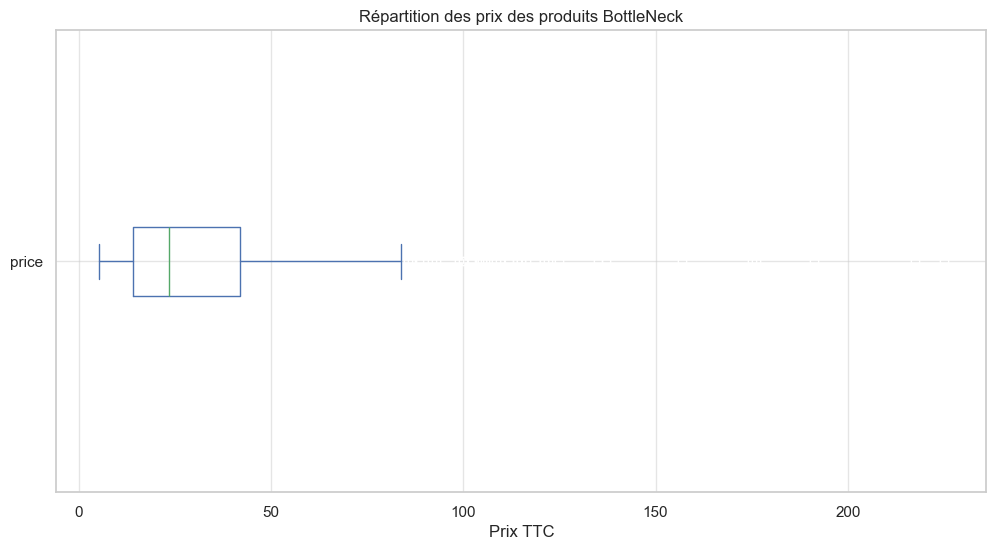

In [60]:
# Boîte à moustaches de la répartition des prix avec Pandas / Matplotlib

ax = df_analyse["price"].plot(kind="box", vert=False, title="Répartition des prix des produits BottleNeck")
ax.set_xlabel("Prix TTC")
plt.show()

In [61]:
# Analyse visuelle des prix extrêmes
# Version statique compatible PyCharm : évite les blocages possibles de Plotly dans certains environnements.

colonnes_prix_extremes = [col for col in ["product_id", "sku", "post_title", "price", "total_sales"] if col in df_analyse.columns]
prix_extremes = df_analyse.sort_values("price", ascending=False)[colonnes_prix_extremes].head(20)

afficher_tableau(prix_extremes, "Top 20 des prix les plus élevés")


,product_id,sku,post_title,price,total_sales
208,4 352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,"225,00 €",11
460,5 001,14581,David Duband Charmes-Chambertin Grand Cru 2014,"217,50 €",2
635,5 892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,"191,30 €",6
227,4 402,3510,Cognac Frapin VIP XO,"176,00 €",3
598,5 767,15185,Camille Giroud Clos de Vougeot 2016,"175,00 €",4
230,4 406,7819,Cognac Frapin Château de Fontpinot 1989 20 Ans d'Age,"157,00 €",4
411,4 904,14220,Domaine Des Croix Corton Charlemagne Grand Cru 2016,"137,00 €",3
697,6 126,14923,Champagne Gosset Célébris Vintage 2007,"135,00 €",5
556,5 612,14915,Domaine Weinbach Gewurztraminer Grand Cru Furstentum SGN 2010 1/2,"124,80 €",1
651,5 917,14775,Wemyss Malts Single Cask Scotch Whisky Choc 'n' Nut Pretzel 2001 Bunnahabhain,"122,00 €",3


,product_id,sku,post_title,price,total_sales
208,4352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.00,11.00
460,5001,14581,David Duband Charmes-Chambertin Grand Cru 2014,217.50,2.00
635,5892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.30,6.00
227,4402,3510,Cognac Frapin VIP XO,176.00,3.00
598,5767,15185,Camille Giroud Clos de Vougeot 2016,175.00,4.00
230,4406,7819,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.00,4.00
411,4904,14220,Domaine Des Croix Corton Charlemagne Grand Cru...,137.00,3.00
697,6126,14923,Champagne Gosset Célébris Vintage 2007,135.00,5.00
556,5612,14915,Domaine Weinbach Gewurztraminer Grand Cru Furs...,124.80,1.00
651,5917,14775,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,122.00,3.00


<a id="section-4-2"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        4.2 — Identification statistique des valeurs aberrantes
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Application de méthodes statistiques pour repérer les prix atypiques.</p>
</div>

<a id="section-4-2-1"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        4.2.1 — Identification par le Z-score
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Un Z-score supérieur à 3 en valeur absolue indique généralement une valeur très éloignée de la moyenne.</p>
</div>

In [62]:
# Calcul de la moyenne, de l'écart-type et du Z-score sur le prix

prix_moyen = df_analyse["price"].mean()
prix_ecart_type = df_analyse["price"].std()

df_analyse["z_score_price"] = (df_analyse["price"] - prix_moyen) / prix_ecart_type

resume_z_score = pd.DataFrame({
    "Indicateur": ["Prix moyen", "Écart-type du prix"],
    "Valeur": [prix_moyen, prix_ecart_type]
})

afficher_tableau(resume_z_score)

Indicateur,Valeur
Prix moyen,"32,33"
Écart-type du prix,"27,60"


,Indicateur,Valeur
0,Prix moyen,32.33
1,Écart-type du prix,27.60


In [63]:
# Articles dont le Z-score du prix est supérieur à 3 en valeur absolue

outliers_zscore_prix = df_analyse[df_analyse["z_score_price"].abs() > 3].copy()
outliers_zscore_prix = outliers_zscore_prix.sort_values("price", ascending=False)

print(f"Nombre d'outliers détectés avec le Z-score : {len(outliers_zscore_prix)}")
afficher_tableau(outliers_zscore_prix[[col for col in ["product_id", "sku", "post_title", "price", "z_score_price"] if col in outliers_zscore_prix.columns]])

Nombre d'outliers détectés avec le Z-score : 13


,product_id,sku,post_title,price,z_score_price
208,4 352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,"225,00 €","6,98 €"
460,5 001,14581,David Duband Charmes-Chambertin Grand Cru 2014,"217,50 €","6,71 €"
635,5 892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,"191,30 €","5,76 €"
227,4 402,3510,Cognac Frapin VIP XO,"176,00 €","5,21 €"
598,5 767,15185,Camille Giroud Clos de Vougeot 2016,"175,00 €","5,17 €"
230,4 406,7819,Cognac Frapin Château de Fontpinot 1989 20 Ans d'Age,"157,00 €","4,52 €"
411,4 904,14220,Domaine Des Croix Corton Charlemagne Grand Cru 2016,"137,00 €","3,79 €"
697,6 126,14923,Champagne Gosset Célébris Vintage 2007,"135,00 €","3,72 €"
556,5 612,14915,Domaine Weinbach Gewurztraminer Grand Cru Furstentum SGN 2010 1/2,"124,80 €","3,35 €"
651,5 917,14775,Wemyss Malts Single Cask Scotch Whisky Choc 'n' Nut Pretzel 2001 Bunnahabhain,"122,00 €","3,25 €"


,product_id,sku,post_title,price,z_score_price
208,4352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.00,6.98
460,5001,14581,David Duband Charmes-Chambertin Grand Cru 2014,217.50,6.71
635,5892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.30,5.76
227,4402,3510,Cognac Frapin VIP XO,176.00,5.21
598,5767,15185,Camille Giroud Clos de Vougeot 2016,175.00,5.17
230,4406,7819,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.00,4.52
411,4904,14220,Domaine Des Croix Corton Charlemagne Grand Cru...,137.00,3.79
697,6126,14923,Champagne Gosset Célébris Vintage 2007,135.00,3.72
556,5612,14915,Domaine Weinbach Gewurztraminer Grand Cru Furs...,124.80,3.35
651,5917,14775,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,122.00,3.25


<a id="section-4-2-2"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        4.2.2 — Identification par l’écart interquartile
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">La méthode IQR isole les valeurs situées au-delà de Q1 - 1,5×IQR ou Q3 + 1,5×IQR.</p>
</div>

In [64]:
# Mesures de dispersion du prix

afficher_tableau(df_analyse[["price"]].describe())

,price
count,"714,00 €"
mean,"32,33 €"
std,"27,60 €"
min,"5,20 €"
25%,"14,06 €"
50%,"23,45 €"
75%,"42,08 €"
max,"225,00 €"


,price
count,714.00
mean,32.33
std,27.60
min,5.20
25%,14.06
50%,23.45
75%,42.08
max,225.00


In [65]:
# Calcul des seuils IQR

q1 = df_analyse["price"].quantile(0.25)
q3 = df_analyse["price"].quantile(0.75)
iqr = q3 - q1

seuil_bas_iqr = q1 - 1.5 * iqr
seuil_haut_iqr = q3 + 1.5 * iqr

resume_iqr = pd.DataFrame({
    "Indicateur": ["Q1", "Q3", "IQR", "Seuil bas", "Seuil haut"],
    "Valeur": [q1, q3, iqr, seuil_bas_iqr, seuil_haut_iqr]
})

afficher_tableau(resume_iqr)

Indicateur,Valeur
Q1,"14,06"
Q3,"42,08"
IQR,"28,01"
Seuil bas,"-27,96"
Seuil haut,"84,09"


,Indicateur,Valeur
0,Q1,14.06
1,Q3,42.08
2,IQR,28.01
3,Seuil bas,-27.96
4,Seuil haut,84.09


In [66]:
# Identification des outliers de prix selon l'IQR

outliers_iqr_prix = df_analyse[
    (df_analyse["price"] < seuil_bas_iqr) | (df_analyse["price"] > seuil_haut_iqr)
].copy().sort_values("price", ascending=False)

proportion_outliers_iqr = len(outliers_iqr_prix) / len(df_analyse) * 100 if len(df_analyse) > 0 else 0

print(f"Nombre d'articles outliers selon l'IQR : {len(outliers_iqr_prix)}")
print(f"Proportion du catalogue : {proportion_outliers_iqr:.2f} %")

afficher_tableau(outliers_iqr_prix[[col for col in ["product_id", "sku", "post_title", "price", "total_sales"] if col in outliers_iqr_prix.columns]])

Nombre d'articles outliers selon l'IQR : 31
Proportion du catalogue : 4.34 %


,product_id,sku,post_title,price,total_sales
208,4 352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,"225,00 €",11
460,5 001,14581,David Duband Charmes-Chambertin Grand Cru 2014,"217,50 €",2
635,5 892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,"191,30 €",6
227,4 402,3510,Cognac Frapin VIP XO,"176,00 €",3
598,5 767,15185,Camille Giroud Clos de Vougeot 2016,"175,00 €",4
230,4 406,7819,Cognac Frapin Château de Fontpinot 1989 20 Ans d'Age,"157,00 €",4
411,4 904,14220,Domaine Des Croix Corton Charlemagne Grand Cru 2016,"137,00 €",3
697,6 126,14923,Champagne Gosset Célébris Vintage 2007,"135,00 €",5
556,5 612,14915,Domaine Weinbach Gewurztraminer Grand Cru Furstentum SGN 2010 1/2,"124,80 €",1
651,5 917,14775,Wemyss Malts Single Cask Scotch Whisky Choc 'n' Nut Pretzel 2001 Bunnahabhain,"122,00 €",3


,product_id,sku,post_title,price,total_sales
208,4352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.00,11.00
460,5001,14581,David Duband Charmes-Chambertin Grand Cru 2014,217.50,2.00
635,5892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.30,6.00
227,4402,3510,Cognac Frapin VIP XO,176.00,3.00
598,5767,15185,Camille Giroud Clos de Vougeot 2016,175.00,4.00
230,4406,7819,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.00,4.00
411,4904,14220,Domaine Des Croix Corton Charlemagne Grand Cru...,137.00,3.00
697,6126,14923,Champagne Gosset Célébris Vintage 2007,135.00,5.00
556,5612,14915,Domaine Weinbach Gewurztraminer Grand Cru Furs...,124.80,1.00
651,5917,14775,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,122.00,3.00


<div style="
    background-color: #F4FAFB;
    border-left: 6px solid #33A5B6;
    padding: 16px 20px;
    margin: 16px 0 20px 0;
    border-radius: 8px;
">
    <strong style="color:#1E7D8B; font-family:Arial, sans-serif;">Conclusion sur les prix</strong>
    <p style="margin: 8px 0 0 0; color:#34495E; font-family:Arial, sans-serif; font-size:14px; line-height:1.6;">
        Les prix identifiés comme atypiques doivent être analysés avec prudence : dans un catalogue de vins, un prix élevé peut correspondre à un produit premium et ne constitue pas automatiquement une erreur. Ces produits sont donc isolés pour contrôle métier plutôt que supprimés.
    </p>
</div>

<a id="etape-5"></a>
<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 12px;
    padding: 24px 28px;
    margin: 18px 0 24px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.18);
">
    <h2 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 30px;
        font-weight: bold;
    ">
        Étape 5 — Analyses métier
    </h2>
    <p style="margin: 10px 0 0 0; color: #EAF9FC; font-family: Arial, sans-serif; font-size: 15px; line-height: 1.5;">Objectif : analyser le chiffre d’affaires, les quantités vendues, les stocks, les marges et les corrélations.</p>
</div>

<a id="section-5-1"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        5.1 — Analyse du chiffre d’affaires
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Calcul du chiffre d’affaires par produit et du chiffre d’affaires total du site Web.</p>
</div>

In [67]:
# Calcul du CA par article
# Les lignes dont le prix ou les ventes sont invalides sont conservées dans la base,
# mais exclues du chiffre d'affaires avec un CA forcé à 0 pour éviter les résultats NaN.

df_analyse["ca_par_article"] = np.where(
    df_analyse["donnee_ca_valide"],
    df_analyse["price"] * df_analyse["total_sales"],
    0
)

ca_total = df_analyse.loc[df_analyse["donnee_ca_valide"], "ca_par_article"].sum()
nb_lignes_ca_exclues = int((~df_analyse["donnee_ca_valide"]).sum())

print(f"Chiffre d'affaires total du site Web : {ca_total:,.2f} €")
print(f"Lignes exclues du calcul du CA pour prix ou ventes invalides : {nb_lignes_ca_exclues}")


Chiffre d'affaires total du site Web : 143,680.10 €
Lignes exclues du calcul du CA pour prix ou ventes invalides : 0


In [68]:
# Palmarès des 20 articles générant le plus de CA

top20_ca = (
    df_analyse[df_analyse["donnee_ca_valide"]]
    .sort_values("ca_par_article", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

afficher_tableau(top20_ca[[col for col in ["product_id", "sku", "post_title", "price", "total_sales", "ca_par_article"] if col in top20_ca.columns]])


product_id,sku,post_title,price,total_sales,ca_par_article
4 352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,"225,00 €",11,"2 475,00 €"
5 892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,"191,30 €",6,"1 147,80 €"
4 353,12587,Champagne Egly-Ouriet Grand Cru Brut Rosé,"79,50 €",14,"1 113,00 €"
5 826,15325,Agnès Levet Côte Rôtie Améthyste 2017,"41,20 €",20,"824,00 €"
6 212,13996,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2015,"115,00 €",7,"805,00 €"
5 026,13913,Champagne Agrapart &amp; Fils Minéral Extra Brut Blanc de Blancs Grand Cru 2012,"86,80 €",9,"781,20 €"
5 008,11602,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2013,"105,00 €",7,"735,00 €"
5 767,15185,Camille Giroud Clos de Vougeot 2016,"175,00 €",4,"700,00 €"
6 126,14923,Champagne Gosset Célébris Vintage 2007,"135,00 €",5,"675,00 €"
5 025,13914,Champagne Agrapart &amp; Fils L'Avizoise Extra Brut Blanc de Blancs Grand Cru 2012,"112,00 €",6,"672,00 €"


,product_id,sku,post_title,price,total_sales,ca_par_article
0,4352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.00,11.00,"2,475.00"
1,5892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.30,6.00,"1,147.80"
2,4353,12587,Champagne Egly-Ouriet Grand Cru Brut Rosé,79.50,14.00,"1,113.00"
3,5826,15325,Agnès Levet Côte Rôtie Améthyste 2017,41.20,20.00,824.00
4,6212,13996,Domaine des Comtes Lafon Volnay 1er Cru Santen...,115.00,7.00,805.00
5,5026,13913,Champagne Agrapart &amp; Fils Minéral Extra Br...,86.80,9.00,781.20
6,5008,11602,Domaine des Comtes Lafon Volnay 1er Cru Santen...,105.00,7.00,735.00
7,5767,15185,Camille Giroud Clos de Vougeot 2016,175.00,4.00,700.00
8,6126,14923,Champagne Gosset Célébris Vintage 2007,135.00,5.00,675.00
9,5025,13914,Champagne Agrapart &amp; Fils L'Avizoise Extra...,112.00,6.00,672.00


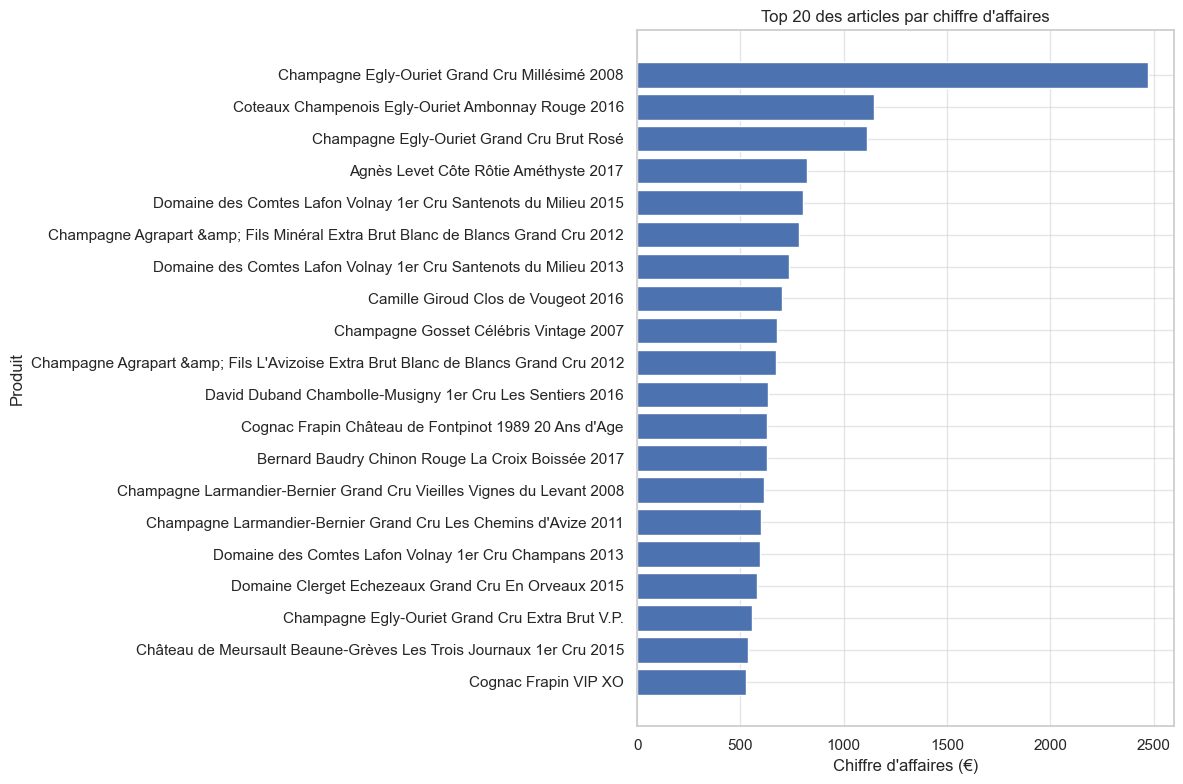

In [69]:
# Graphique en barre des 20 premiers articles en chiffre d'affaires
# Version Matplotlib compatible avec PyCharm et Jupyter, sans dépendre du rendu Plotly.

data_graph = top20_ca.sort_values("ca_par_article")
y_col = "post_title" if "post_title" in data_graph.columns else "product_id"

plt.figure(figsize=(12, 8))
plt.barh(data_graph[y_col].astype(str), data_graph["ca_par_article"])
plt.xlabel("Chiffre d'affaires (€)")
plt.ylabel("Produit")
plt.title("Top 20 des articles par chiffre d'affaires")
plt.tight_layout()
plt.show()


In [70]:
# Analyse 20/80 du chiffre d'affaires

df_ca_8020 = df_analyse[df_analyse["donnee_ca_valide"] & (df_analyse["ca_par_article"] > 0)].sort_values("ca_par_article", ascending=False).copy()
total_ca_8020 = df_ca_8020["ca_par_article"].sum()

if total_ca_8020 > 0:
    df_ca_8020["part_ca"] = df_ca_8020["ca_par_article"] / total_ca_8020
    df_ca_8020["part_ca_cumulee"] = df_ca_8020["part_ca"].cumsum()

    produits_80_ca = df_ca_8020[df_ca_8020["part_ca_cumulee"] <= 0.80].copy()
    # Ajouter le premier produit qui fait dépasser 80 %, pour être plus juste
    if len(produits_80_ca) < len(df_ca_8020):
        produits_80_ca = df_ca_8020.iloc[:len(produits_80_ca) + 1].copy()

    nb_produits_80_ca = len(produits_80_ca)
    proportion_produits_80_ca = nb_produits_80_ca / len(df_ca_8020) * 100 if len(df_ca_8020) > 0 else 0

    print(f"Nombre de produits représentant environ 80 % du CA : {nb_produits_80_ca}")
    print(f"Proportion du catalogue avec CA positif : {proportion_produits_80_ca:.2f} %")

    afficher_tableau(produits_80_ca[[col for col in ["product_id", "sku", "post_title", "ca_par_article", "part_ca", "part_ca_cumulee"] if col in produits_80_ca.columns]].head(20))
else:
    afficher_message("Analyse 20/80 CA impossible : aucun chiffre d'affaires positif exploitable.", "warning")


Nombre de produits représentant environ 80 % du CA : 435
Proportion du catalogue avec CA positif : 63.13 %


,product_id,sku,post_title,ca_par_article,part_ca,part_ca_cumulee
208,4 352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,"2 475,00 €","1,72%","1,72%"
635,5 892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,"1 147,80 €","0,80%","2,52%"
209,4 353,12587,Champagne Egly-Ouriet Grand Cru Brut Rosé,"1 113,00 €","0,77%","3,30%"
630,5 826,15325,Agnès Levet Côte Rôtie Améthyste 2017,"824,00 €","0,57%","3,87%"
708,6 212,13996,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2015,"805,00 €","0,56%","4,43%"
476,5 026,13913,Champagne Agrapart &amp; Fils Minéral Extra Brut Blanc de Blancs Grand Cru 2012,"781,20 €","0,54%","4,97%"
466,5 008,11602,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2013,"735,00 €","0,51%","5,49%"
598,5 767,15185,Camille Giroud Clos de Vougeot 2016,"700,00 €","0,49%","5,97%"
697,6 126,14923,Champagne Gosset Célébris Vintage 2007,"675,00 €","0,47%","6,44%"
475,5 025,13914,Champagne Agrapart &amp; Fils L'Avizoise Extra Brut Blanc de Blancs Grand Cru 2012,"672,00 €","0,47%","6,91%"


<a id="section-5-2"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        5.2 — Analyse des ventes en quantité
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Classement des références selon les quantités vendues et analyse 20/80 en volume.</p>
</div>

In [71]:
# Palmarès des 20 articles les plus vendus en quantité

top20_quantite = df_analyse.sort_values("total_sales", ascending=False).head(20).reset_index(drop=True)

afficher_tableau(top20_quantite[[col for col in ["product_id", "sku", "post_title", "price", "total_sales", "ca_par_article"] if col in top20_quantite.columns]])

product_id,sku,post_title,price,total_sales,ca_par_article
4 867,16148,Château De La Selve IGP Coteaux de l'Ardèche Maguelonne Rosé 2019,"9,90 €",36,"356,40 €"
4 203,15415,Mas Laval IGP Pays d'Hérault Les Pampres Blancs 2018,"9,90 €",27,"267,30 €"
4 275,14864,I Fabbri Chianti Classico Lamole 2017,"14,90 €",24,"357,60 €"
4 647,16525,Bernard Baudry Chinon Rouge La Croix Boissée 2017,"28,50 €",22,"627,00 €"
4 726,14950,François Baur Pinot Noir Schlittweg 2017,"12,70 €",22,"279,40 €"
6 129,14570,Moulin de Gassac IGP Pays d'Hérault Guilhem Blanc 2017,"5,20 €",20,"104,00 €"
5 826,15325,Agnès Levet Côte Rôtie Améthyste 2017,"41,20 €",20,"824,00 €"
4 220,15758,Xavier Frissant Touraine Amboise Chenin Les Pierres 2018,"11,60 €",18,"208,80 €"
5 778,15561,Maurel Pays d'Oc Merlot 2018,"5,80 €",17,"98,60 €"
5 803,13572,Château Tour Haut-Caussan Médoc 2015,"17,10 €",17,"290,70 €"


,product_id,sku,post_title,price,total_sales,ca_par_article
0,4867,16148,Château De La Selve IGP Coteaux de l'Ardèche M...,9.90,36.00,356.40
1,4203,15415,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,9.90,27.00,267.30
2,4275,14864,I Fabbri Chianti Classico Lamole 2017,14.90,24.00,357.60
3,4647,16525,Bernard Baudry Chinon Rouge La Croix Boissée 2017,28.50,22.00,627.00
4,4726,14950,François Baur Pinot Noir Schlittweg 2017,12.70,22.00,279.40
5,6129,14570,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,5.20,20.00,104.00
6,5826,15325,Agnès Levet Côte Rôtie Améthyste 2017,41.20,20.00,824.00
7,4220,15758,Xavier Frissant Touraine Amboise Chenin Les Pi...,11.60,18.00,208.80
8,5778,15561,Maurel Pays d'Oc Merlot 2018,5.80,17.00,98.60
9,5803,13572,Château Tour Haut-Caussan Médoc 2015,17.10,17.00,290.70


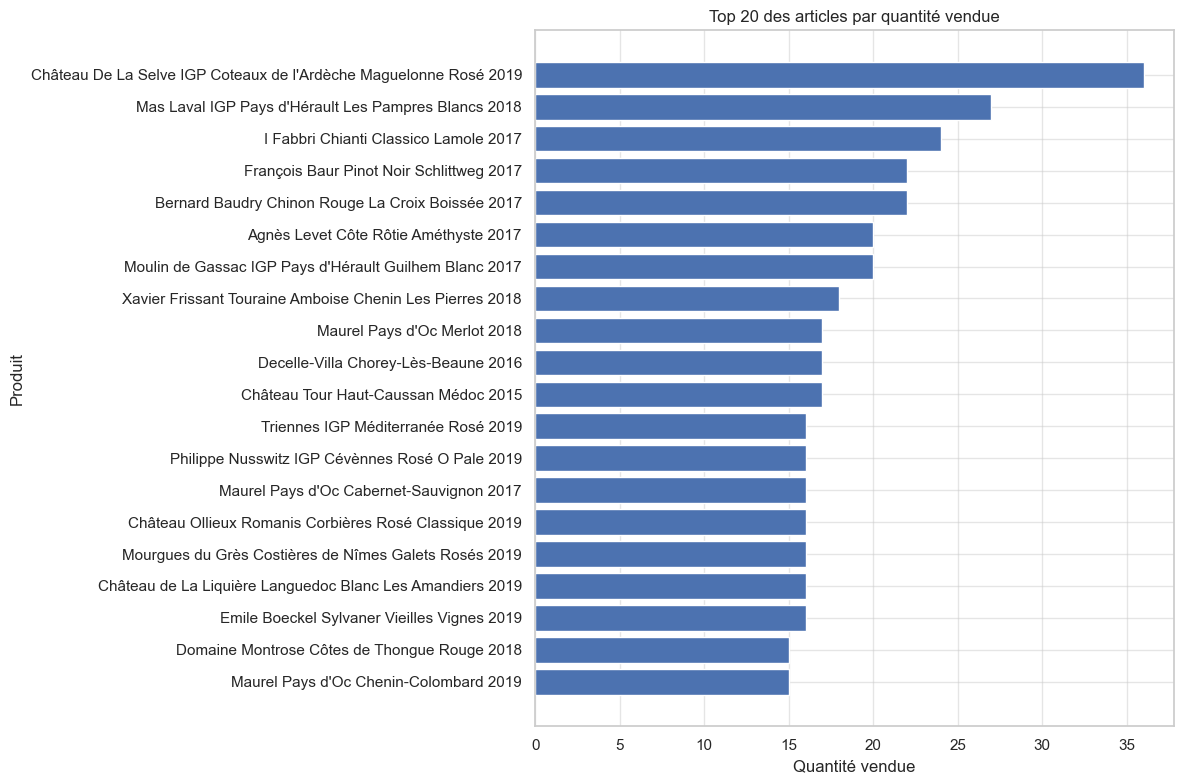

In [72]:
# Graphique en barre des 20 premiers articles en quantité vendue
# Version Matplotlib compatible avec PyCharm et Jupyter.

data_graph = top20_quantite.sort_values("total_sales")
y_col = "post_title" if "post_title" in data_graph.columns else "product_id"

plt.figure(figsize=(12, 8))
plt.barh(data_graph[y_col].astype(str), data_graph["total_sales"])
plt.xlabel("Quantité vendue")
plt.ylabel("Produit")
plt.title("Top 20 des articles par quantité vendue")
plt.tight_layout()
plt.show()


In [73]:
# Analyse 20/80 des ventes en quantité

df_qte_8020 = df_analyse[df_analyse["donnee_vente_valide"] & (df_analyse["total_sales"] > 0)].sort_values("total_sales", ascending=False).copy()
total_quantite_8020 = df_qte_8020["total_sales"].sum()

if total_quantite_8020 > 0:
    df_qte_8020["part_quantite"] = df_qte_8020["total_sales"] / total_quantite_8020
    df_qte_8020["part_quantite_cumulee"] = df_qte_8020["part_quantite"].cumsum()

    produits_80_quantite = df_qte_8020[df_qte_8020["part_quantite_cumulee"] <= 0.80].copy()
    if len(produits_80_quantite) < len(df_qte_8020):
        produits_80_quantite = df_qte_8020.iloc[:len(produits_80_quantite) + 1].copy()

    nb_produits_80_quantite = len(produits_80_quantite)
    proportion_produits_80_quantite = nb_produits_80_quantite / len(df_qte_8020) * 100 if len(df_qte_8020) > 0 else 0

    print(f"Nombre de produits représentant environ 80 % des quantités vendues : {nb_produits_80_quantite}")
    print(f"Proportion du catalogue avec ventes positives : {proportion_produits_80_quantite:.2f} %")

    afficher_tableau(produits_80_quantite[[col for col in ["product_id", "sku", "post_title", "total_sales", "part_quantite", "part_quantite_cumulee"] if col in produits_80_quantite.columns]].head(20))
else:
    afficher_message("Analyse 20/80 quantité impossible : aucune vente positive exploitable.", "warning")


Nombre de produits représentant environ 80 % des quantités vendues : 434
Proportion du catalogue avec ventes positives : 62.99 %


,product_id,sku,post_title,total_sales,part_quantite,part_quantite_cumulee
393,4 867,16148,Château De La Selve IGP Coteaux de l'Ardèche Maguelonne Rosé 2019,36,"0,63%","0,63%"
126,4 203,15415,Mas Laval IGP Pays d'Hérault Les Pampres Blancs 2018,27,"0,47%","1,10%"
181,4 275,14864,I Fabbri Chianti Classico Lamole 2017,24,"0,42%","1,51%"
344,4 726,14950,François Baur Pinot Noir Schlittweg 2017,22,"0,38%","1,90%"
281,4 647,16525,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22,"0,38%","2,28%"
630,5 826,15325,Agnès Levet Côte Rôtie Améthyste 2017,20,"0,35%","2,63%"
700,6 129,14570,Moulin de Gassac IGP Pays d'Hérault Guilhem Blanc 2017,20,"0,35%","2,97%"
140,4 220,15758,Xavier Frissant Touraine Amboise Chenin Les Pierres 2018,18,"0,31%","3,29%"
606,5 778,15561,Maurel Pays d'Oc Merlot 2018,17,"0,30%","3,58%"
730,6 569,15705,Decelle-Villa Chorey-Lès-Beaune 2016,17,"0,30%","3,88%"


<a id="section-5-3"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        5.3 — Analyse des stocks
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Calcul du nombre de mois de stock, valorisation des stocks et identification des références à surveiller.</p>
</div>

In [74]:
# Calcul du nombre de mois de stock
# Hypothèse : total_sales correspond aux ventes du mois d'octobre.
# mois_stock = stock_quantity / total_sales uniquement si les ventes sont strictement positives.

masque_mois_stock = (
    df_analyse["donnee_stock_valide"]
    & df_analyse["donnee_vente_valide"]
    & (df_analyse["total_sales"] > 0)
)

df_analyse["mois_stock_calculable"] = masque_mois_stock
df_analyse["mois_stock"] = 0.0
df_analyse.loc[masque_mois_stock, "mois_stock"] = (
    df_analyse.loc[masque_mois_stock, "stock_quantity"]
    / df_analyse.loc[masque_mois_stock, "total_sales"]
)

# Produits avec le plus de mois de stock, en excluant les produits sans ventes positives
flop20_mois_stock = df_analyse[df_analyse["mois_stock_calculable"]].sort_values("mois_stock", ascending=False).head(20)

print(f"Produits exclus du calcul des mois de stock : {int((~df_analyse['mois_stock_calculable']).sum())}")
afficher_tableau(flop20_mois_stock[[col for col in ["product_id", "sku", "post_title", "stock_quantity", "total_sales", "mois_stock"] if col in flop20_mois_stock.columns]])


Produits exclus du calcul des mois de stock : 26


,product_id,sku,post_title,stock_quantity,total_sales,mois_stock
73,4 142,11641,Champagne Gosset Grand Millésime 2006,125,4,31
697,6 126,14923,Champagne Gosset Célébris Vintage 2007,138,5,28
211,4 356,12585,Champagne Egly-Ouriet Premier Cru Les Vignes de Vrigny,81,3,27
206,4 348,12586,Champagne Egly-Ouriet Grand Cru Brut Tradition,125,5,25
77,4 148,1364,Champagne Mailly Grand Cru Brut Rosé,71,3,24
212,4 357,9562,Champagne Larmandier-Bernier Latitude,115,5,23
74,4 144,1662,Champagne Gosset Grand Rosé,91,4,23
475,5 025,13914,Champagne Agrapart &amp; Fils L'Avizoise Extra Brut Blanc de Blancs Grand Cru 2012,136,6,23
207,4 350,12588,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,145,7,21
79,4 150,1366,Champagne Mailly Grand Cru Intemporelle 2010,123,6,20


,product_id,sku,post_title,stock_quantity,total_sales,mois_stock
73,4142,11641,Champagne Gosset Grand Millésime 2006,125,4.00,31.25
697,6126,14923,Champagne Gosset Célébris Vintage 2007,138,5.00,27.60
211,4356,12585,Champagne Egly-Ouriet Premier Cru Les Vignes d...,81,3.00,27.00
206,4348,12586,Champagne Egly-Ouriet Grand Cru Brut Tradition,125,5.00,25.00
77,4148,1364,Champagne Mailly Grand Cru Brut Rosé,71,3.00,23.67
212,4357,9562,Champagne Larmandier-Bernier Latitude,115,5.00,23.00
74,4144,1662,Champagne Gosset Grand Rosé,91,4.00,22.75
475,5025,13914,Champagne Agrapart &amp; Fils L'Avizoise Extra...,136,6.00,22.67
207,4350,12588,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,145,7.00,20.71
79,4150,1366,Champagne Mailly Grand Cru Intemporelle 2010,123,6.00,20.50


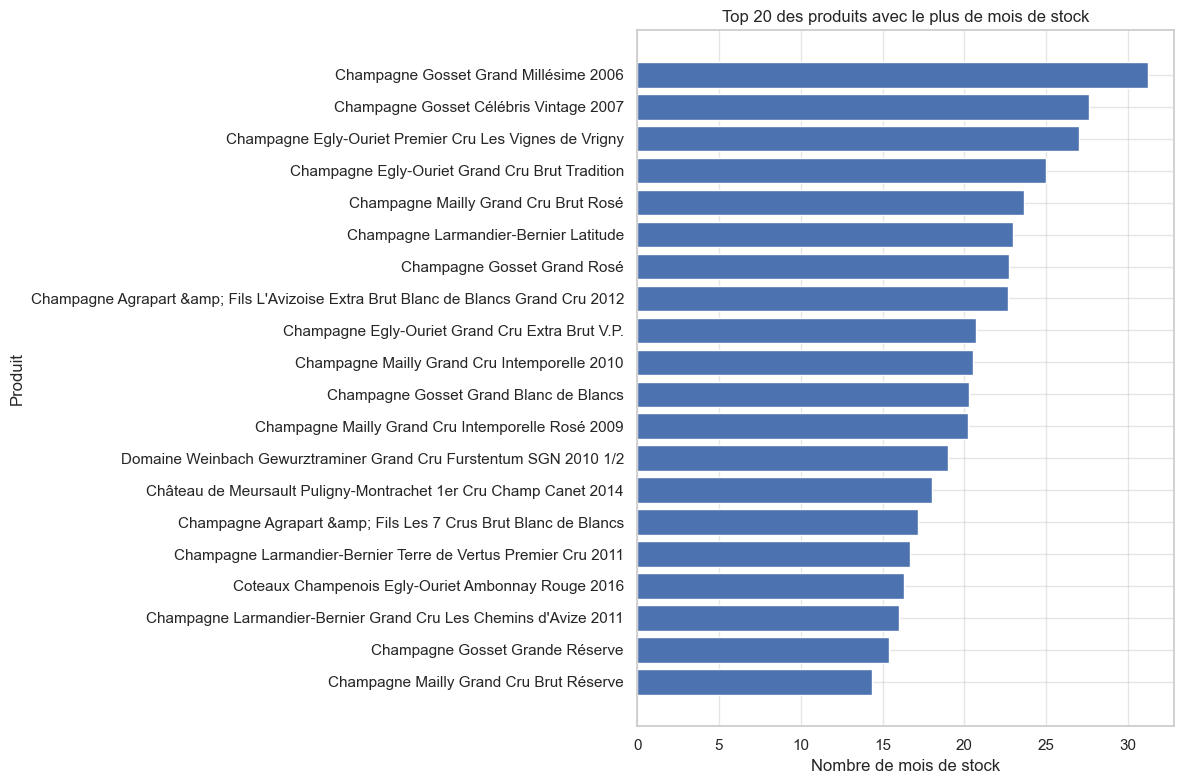

In [75]:
# Graphique des 20 produits avec le plus de mois de stock
# Version Matplotlib compatible avec PyCharm et Jupyter.

data_graph = flop20_mois_stock.sort_values("mois_stock")
y_col = "post_title" if "post_title" in data_graph.columns else "product_id"

plt.figure(figsize=(12, 8))
plt.barh(data_graph[y_col].astype(str), data_graph["mois_stock"])
plt.xlabel("Nombre de mois de stock")
plt.ylabel("Produit")
plt.title("Top 20 des produits avec le plus de mois de stock")
plt.tight_layout()
plt.show()


In [76]:
# Valorisation des stocks en euros
# Valorisation au coût d'achat et valorisation au prix de vente TTC

df_analyse["valorisation_stock_achat"] = df_analyse["stock_quantity"] * df_analyse["purchase_price"]
df_analyse["valorisation_stock_vente_ttc"] = df_analyse["stock_quantity"] * df_analyse["price"]

valorisation_stock_achat_total = df_analyse["valorisation_stock_achat"].sum()
valorisation_stock_vente_total = df_analyse["valorisation_stock_vente_ttc"].sum()
nombre_produits_stock_total = df_analyse["stock_quantity"].sum()

resume_stock = pd.DataFrame({
    "Indicateur": [
        "Nombre total d'unités en stock",
        "Valorisation du stock au prix d'achat",
        "Valorisation du stock au prix de vente TTC"
    ],
    "Valeur": [
        nombre_produits_stock_total,
        valorisation_stock_achat_total,
        valorisation_stock_vente_total
    ]
})

afficher_tableau(resume_stock)

Indicateur,Valeur
Nombre total d'unités en stock,"16 739,00"
Valorisation du stock au prix d'achat,"277 305,77"
Valorisation du stock au prix de vente TTC,"494 593,40"


,Indicateur,Valeur
0,Nombre total d'unités en stock,"16,739.00"
1,Valorisation du stock au prix d'achat,"277,305.77"
2,Valorisation du stock au prix de vente TTC,"494,593.40"


In [77]:
# Produits sans vente mais avec stock disponible : stock dormant potentiel

stock_dormant = df_analyse[(df_analyse["total_sales"] == 0) & (df_analyse["stock_quantity"] > 0)].copy()
stock_dormant = stock_dormant.sort_values("stock_quantity", ascending=False)

print(f"Nombre de produits sans vente mais avec stock disponible : {len(stock_dormant)}")
afficher_tableau(stock_dormant[[col for col in ["product_id", "sku", "post_title", "price", "stock_quantity", "total_sales", "valorisation_stock_achat"] if col in stock_dormant.columns]].head(20))

Nombre de produits sans vente mais avec stock disponible : 3


,product_id,sku,post_title,price,stock_quantity,total_sales,valorisation_stock_achat
205,4 337,4679,Champagne Mailly Grand Cru Les Echansons 2007,"83,00 €",145,0,"7 090,50 €"
210,4 355,12589,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,"12,65 €",97,0,"7 515,56 €"
656,5 932,523,Cognac Normandin Mercier VFC,"59,90 €",13,0,"353,34 €"


,product_id,sku,post_title,price,stock_quantity,total_sales,valorisation_stock_achat
205,4337,4679,Champagne Mailly Grand Cru Les Echansons 2007,83.00,145,0.00,"7,090.50"
210,4355,12589,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,12.65,97,0.00,"7,515.56"
656,5932,523,Cognac Normandin Mercier VFC,59.90,13,0.00,353.34


<a id="section-5-4"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        5.4 — Analyse du taux de marge
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Calcul du prix HT, de la marge unitaire et du taux de marge.</p>
</div>

In [78]:
# Calcul de la marge
# Hypothèse : les prix du fichier ERP sont des prix TTC et la TVA appliquée est de 20 %.

TAUX_TVA = 0.20

df_analyse["prix_ht"] = df_analyse["price"] / (1 + TAUX_TVA)
df_analyse["marge_unitaire"] = df_analyse["prix_ht"] - df_analyse["purchase_price"]
df_analyse["donnee_marge_valide"] = (
    df_analyse["donnee_prix_valide"]
    & df_analyse["purchase_price"].notna()
    & (df_analyse["purchase_price"] > 0)
)
df_analyse["taux_marge"] = 0.0
df_analyse.loc[df_analyse["donnee_marge_valide"], "taux_marge"] = (
    df_analyse.loc[df_analyse["donnee_marge_valide"], "marge_unitaire"]
    / df_analyse.loc[df_analyse["donnee_marge_valide"], "purchase_price"]
    * 100
)
df_analyse["marge_totale"] = np.where(
    df_analyse["donnee_marge_valide"] & df_analyse["donnee_vente_valide"],
    df_analyse["marge_unitaire"] * df_analyse["total_sales"],
    0
)

serie_taux_marge_valide = df_analyse.loc[df_analyse["donnee_marge_valide"], "taux_marge"]

resume_marge = pd.DataFrame({
    "Indicateur": [
        "Lignes avec marge calculable",
        "Lignes exclues du calcul de marge",
        "Taux de marge minimum",
        "Taux de marge maximum",
        "Taux de marge moyen",
        "Marge totale estimée"
    ],
    "Valeur": [
        int(df_analyse["donnee_marge_valide"].sum()),
        int((~df_analyse["donnee_marge_valide"]).sum()),
        serie_taux_marge_valide.min() if not serie_taux_marge_valide.empty else 0,
        serie_taux_marge_valide.max() if not serie_taux_marge_valide.empty else 0,
        serie_taux_marge_valide.mean() if not serie_taux_marge_valide.empty else 0,
        df_analyse["marge_totale"].sum()
    ]
})

afficher_tableau(resume_marge)


Indicateur,Valeur
Lignes avec marge calculable,"714,00"
Lignes exclues du calcul de marge,"0,00"
Taux de marge minimum,"-86,39"
Taux de marge maximum,"91,41"
Taux de marge moyen,"61,02"
Marge totale estimée,"44 660,65"


,Indicateur,Valeur
0,Lignes avec marge calculable,714.00
1,Lignes exclues du calcul de marge,0.00
2,Taux de marge minimum,-86.39
3,Taux de marge maximum,91.41
4,Taux de marge moyen,61.02
5,Marge totale estimée,"44,660.65"


In [79]:
# Affichage des produits avec un taux de marge négatif

anomalies_marge_negative = df_analyse[df_analyse["donnee_marge_valide"] & (df_analyse["taux_marge"] < 0)].copy()

print(f"Nombre de produits avec taux de marge négatif : {len(anomalies_marge_negative)}")
afficher_tableau(anomalies_marge_negative[[col for col in ["product_id", "sku", "post_title", "price", "prix_ht", "purchase_price", "marge_unitaire", "taux_marge"] if col in anomalies_marge_negative.columns]])


Nombre de produits avec taux de marge négatif : 1


,product_id,sku,post_title,price,prix_ht,purchase_price,marge_unitaire,taux_marge
210,4 355,12589,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,"12,65 €","10,54 €","77,48 €","-66,94 €","-8639,43%"


,product_id,sku,post_title,price,prix_ht,purchase_price,marge_unitaire,taux_marge
210,4355,12589,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,12.65,10.54,77.48,-66.94,-86.39


In [80]:
# Analyse des taux de marge positifs

df_marges_positives = df_analyse[df_analyse["donnee_marge_valide"] & (df_analyse["taux_marge"] >= 0)].copy()

resume_marge_positive = pd.DataFrame({
    "Indicateur": ["Taux de marge positif minimum", "Taux de marge positif maximum", "Taux de marge positif moyen"],
    "Valeur": [
        df_marges_positives["taux_marge"].min() if not df_marges_positives.empty else 0,
        df_marges_positives["taux_marge"].max() if not df_marges_positives.empty else 0,
        df_marges_positives["taux_marge"].mean() if not df_marges_positives.empty else 0
    ]
})

afficher_tableau(resume_marge_positive)


Indicateur,Valeur
Taux de marge positif minimum,"29,50"
Taux de marge positif maximum,"91,41"
Taux de marge positif moyen,"61,22"


,Indicateur,Valeur
0,Taux de marge positif minimum,29.50
1,Taux de marge positif maximum,91.41
2,Taux de marge positif moyen,61.22


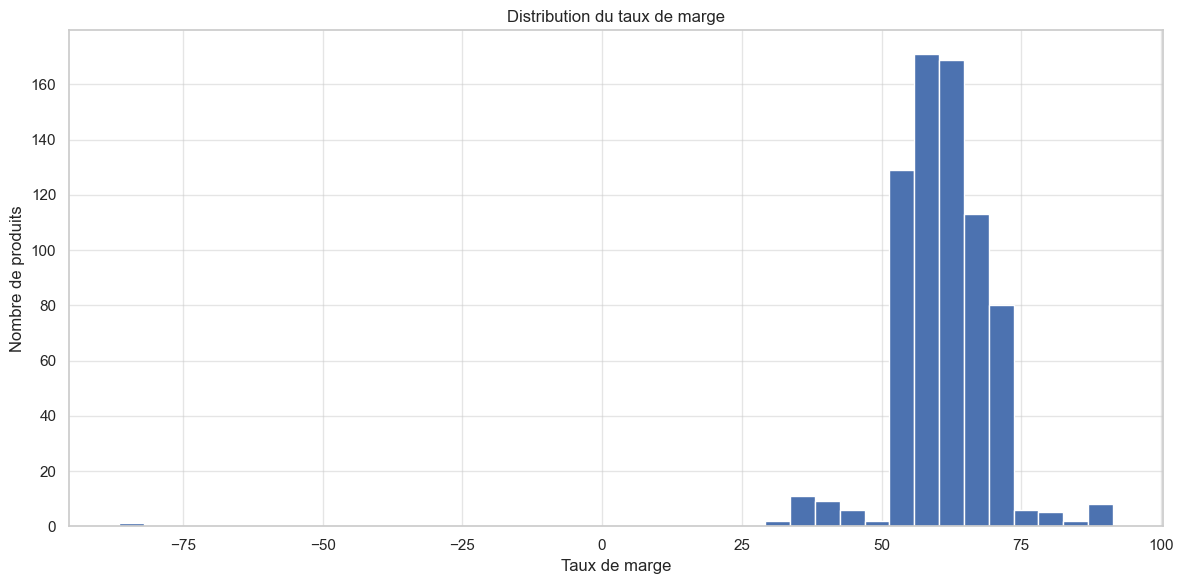

In [81]:
# Graphique de distribution du taux de marge
# Version Matplotlib compatible avec PyCharm et Jupyter.

plt.figure(figsize=(12, 6))
plt.hist(df_analyse.loc[df_analyse["donnee_marge_valide"], "taux_marge"], bins=40)
plt.xlabel("Taux de marge")
plt.ylabel("Nombre de produits")
plt.title("Distribution du taux de marge")
plt.tight_layout()
plt.show()


<a id="section-5-5"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        5.5 — Analyse des corrélations
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Mesure des relations entre prix, prix d’achat, stock, ventes, CA, prix HT et taux de marge.</p>
</div>

In [82]:
# Matrice de corrélation sur les variables quantitatives principales

variables_correlation = [
    "price", "purchase_price", "prix_ht", "taux_marge", "marge_unitaire",
    "stock_quantity", "total_sales", "ca_par_article", "mois_stock", "valorisation_stock_achat"
]
variables_correlation = [colonne for colonne in variables_correlation if colonne in df_analyse.columns]

df_correlation = df_analyse[variables_correlation].replace([np.inf, -np.inf], np.nan).copy()
df_correlation = df_correlation.dropna(axis=1, how="all")
df_correlation = df_correlation[[colonne for colonne in df_correlation.columns if df_correlation[colonne].nunique(dropna=True) > 1]]
df_correlation = df_correlation.dropna(how="any")

if df_correlation.shape[1] >= 2 and len(df_correlation) >= 2:
    matrice_correlation = df_correlation.corr(numeric_only=True)
    afficher_tableau(matrice_correlation)
else:
    matrice_correlation = pd.DataFrame()
    afficher_message("Matrice de corrélation non calculable : données numériques insuffisantes après exclusion des NaN/inf.", "warning")


,price,purchase_price,prix_ht,taux_marge,marge_unitaire,stock_quantity,total_sales,ca_par_article,mois_stock,valorisation_stock_achat
price,"1,00 €","0,98 €","1,00 €","-1,13%","0,94 €",-0,-1,"0,63 €",0,"0,37 €"
purchase_price,"0,98 €","1,00 €","0,98 €","-19,20%","0,84 €",-0,-1,"0,65 €",0,"0,48 €"
prix_ht,"1,00 €","0,98 €","1,00 €","-1,13%","0,94 €",-0,-1,"0,63 €",0,"0,37 €"
taux_marge,"-0,01 €","-0,19 €","-0,01 €","100,00%","0,28 €",-0,0,"-0,13 €",-0,"-0,50 €"
marge_unitaire,"0,94 €","0,84 €","0,94 €","28,37%","1,00 €",-0,-0,"0,53 €",0,"0,16 €"
stock_quantity,"-0,11 €","-0,02 €","-0,11 €","-43,82%","-0,23 €",1,0,"0,17 €",1,"0,72 €"
total_sales,"-0,52 €","-0,50 €","-0,52 €","1,13%","-0,48 €",0,1,"0,11 €",-0,"-0,06 €"
ca_par_article,"0,63 €","0,65 €","0,63 €","-12,83%","0,53 €",0,0,"1,00 €",0,"0,39 €"
mois_stock,"0,20 €","0,25 €","0,20 €","-35,45%","0,11 €",1,-0,"0,18 €",1,"0,71 €"
valorisation_stock_achat,"0,37 €","0,48 €","0,37 €","-50,37%","0,16 €",1,-0,"0,39 €",1,"1,00 €"


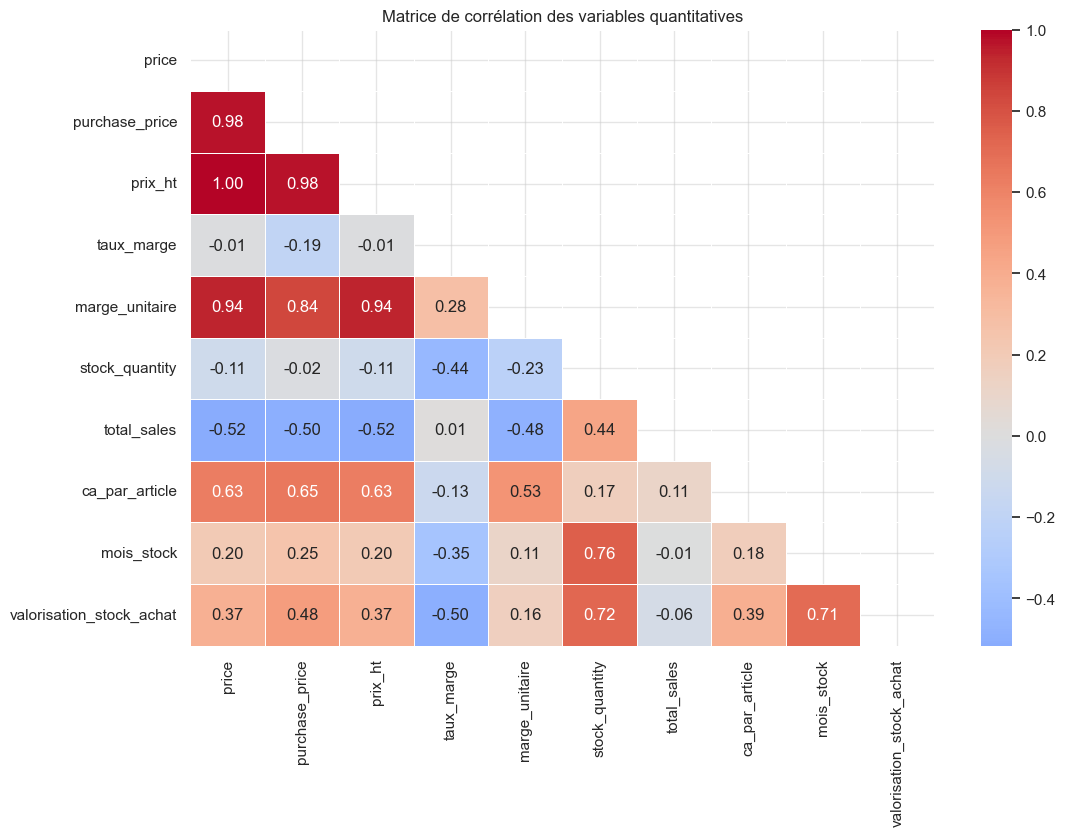

In [83]:
# Heatmap de corrélation

if not matrice_correlation.empty:
    plt.figure(figsize=(12, 8))
    mask = np.triu(np.ones_like(matrice_correlation, dtype=bool))
    sns.heatmap(
        matrice_correlation,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )
    plt.title("Matrice de corrélation des variables quantitatives")
    plt.show()
else:
    afficher_message("Heatmap non affichée car la matrice de corrélation est vide.", "warning")


In [84]:
# Extraction des corrélations les plus fortes en valeur absolue

if not matrice_correlation.empty:
    corr_pairs = (
        matrice_correlation
        .where(~np.eye(matrice_correlation.shape[0], dtype=bool))
        .stack()
        .reset_index()
    )
    corr_pairs.columns = ["Variable 1", "Variable 2", "Corrélation"]
    corr_pairs["Corrélation absolue"] = corr_pairs["Corrélation"].abs()

    corr_pairs_fortes = corr_pairs.sort_values("Corrélation absolue", ascending=False).drop_duplicates(
        subset=["Corrélation absolue", "Corrélation"]
    ).head(15)
else:
    corr_pairs_fortes = pd.DataFrame(columns=["Variable 1", "Variable 2", "Corrélation", "Corrélation absolue"])

afficher_tableau(corr_pairs_fortes)


,Variable 1,Variable 2,Corrélation,Corrélation absolue
2,price,prix_ht,"100,00%","100,00%"
12,purchase_price,prix_ht,"97,60%","97,60%"
10,purchase_price,price,"97,60%","97,60%"
4,price,marge_unitaire,"93,51%","93,51%"
42,marge_unitaire,prix_ht,"93,51%","93,51%"
14,purchase_price,marge_unitaire,"83,53%","83,53%"
58,stock_quantity,mois_stock,"75,59%","75,59%"
59,stock_quantity,valorisation_stock_achat,"71,65%","71,65%"
89,mois_stock,valorisation_stock_achat,"70,70%","70,70%"
71,ca_par_article,purchase_price,"64,71%","64,71%"


,Variable 1,Variable 2,Corrélation,Corrélation absolue
2,price,prix_ht,1.00,1.00
12,purchase_price,prix_ht,0.98,0.98
10,purchase_price,price,0.98,0.98
4,price,marge_unitaire,0.94,0.94
42,marge_unitaire,prix_ht,0.94,0.94
14,purchase_price,marge_unitaire,0.84,0.84
58,stock_quantity,mois_stock,0.76,0.76
59,stock_quantity,valorisation_stock_achat,0.72,0.72
89,mois_stock,valorisation_stock_achat,0.71,0.71
71,ca_par_article,purchase_price,0.65,0.65


<div style="
    background-color: #F4FAFB;
    border-left: 6px solid #33A5B6;
    padding: 16px 20px;
    margin: 16px 0 20px 0;
    border-radius: 8px;
">
    <strong style="color:#1E7D8B; font-family:Arial, sans-serif;">Conclusion sur les corrélations</strong>
    <p style="margin: 8px 0 0 0; color:#34495E; font-family:Arial, sans-serif; font-size:14px; line-height:1.6;">
        Les corrélations permettent d’identifier les relations statistiques entre variables, mais elles ne prouvent pas une causalité. Les résultats doivent donc être interprétés avec prudence et complétés par une analyse métier.
    </p>
</div>

<a id="etape-6"></a>
<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 12px;
    padding: 24px 28px;
    margin: 18px 0 24px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.18);
">
    <h2 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 30px;
        font-weight: bold;
    ">
        Étape 6 — Journal des anomalies et recommandations
    </h2>
    <p style="margin: 10px 0 0 0; color: #EAF9FC; font-family: Arial, sans-serif; font-size: 15px; line-height: 1.5;">Objectif : centraliser les anomalies détectées et proposer des actions pour améliorer la qualité des données.</p>
</div>

<a id="section-6-1"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        6.1 — Journal des anomalies détectées
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Synthèse des principales anomalies repérées pendant l’exploration, le nettoyage et les jointures.</p>
</div>

In [85]:
# Construction d'un journal des anomalies détectées

journal_anomalies = []

def ajouter_anomalie(source, type_anomalie, description, nb_lignes, action_recommandee):
    journal_anomalies.append({
        "Source": source,
        "Type d'anomalie": type_anomalie,
        "Description": description,
        "Nombre de lignes concernées": int(nb_lignes) if pd.notna(nb_lignes) else 0,
        "Action recommandée": action_recommandee
    })

ajouter_anomalie(
    "ERP",
    "Incohérence métier",
    "Écart entre stock_quantity et stock_status.",
    len(anomalies_stock_status),
    "Corriger le statut de stock à partir d'une règle métier validée."
)

ajouter_anomalie(
    "ERP",
    "Prix manquant, nul ou négatif",
    "Produits dont le prix de vente est absent ou incohérent.",
    len(anomalies_prix_erp),
    "Bloquer la mise en vente si le prix est absent, nul ou négatif."
)

ajouter_anomalie(
    "ERP",
    "Stock négatif",
    "Produits dont le stock est inférieur à zéro.",
    len(anomalies_stock_negatif),
    "Contrôler les mouvements de stock et empêcher les saisies négatives non justifiées."
)

ajouter_anomalie(
    "ERP",
    "Prix d'achat manquant, nul ou négatif",
    "Produits dont le prix d'achat ne permet pas de calculer correctement la marge.",
    len(anomalies_purchase_price),
    "Rendre le prix d'achat obligatoire dans l'ERP."
)

ajouter_anomalie(
    "ERP",
    "Prix d'achat supérieur au prix de vente",
    "Produits potentiellement vendus avec une marge négative avant même le calcul HT.",
    len(anomalies_purchase_superieur_price),
    "Contrôler les prix d'achat et les prix de vente lors de la saisie."
)

ajouter_anomalie(
    "Web",
    "SKU absent",
    "Lignes Web sans code article SKU.",
    len(lignes_sans_sku),
    "Supprimer ou exclure les lignes non produit ; rendre le SKU obligatoire pour les produits."
)

ajouter_anomalie(
    "Web",
    "Format SKU à contrôler",
    "SKU ne respectant pas une codification strictement numérique.",
    len(anomalies_sku_format),
    "Vérifier s'il s'agit de vraies références métier ou d'erreurs de saisie."
)

ajouter_anomalie(
    "Web",
    "SKU en doublon",
    "SKU dupliqués sur les lignes produit du fichier Web.",
    nb_doublons_sku_products,
    "Garantir l'unicité du SKU dans WordPress."
)

ajouter_anomalie(
    "Liaison",
    "Article sans id_web",
    "Produits ERP sans correspondance Web dans la table de liaison.",
    len(articles_sans_id_web),
    "Mettre à jour la table de liaison pour chaque produit vendu sur le Web."
)

ajouter_anomalie(
    "Jointure",
    "ERP sans liaison",
    "Produits ERP non retrouvés dans la table de liaison.",
    len(anomalies_erp_sans_liaison),
    "Automatiser un contrôle de couverture entre ERP et liaison."
)

ajouter_anomalie(
    "Jointure",
    "Liaison sans correspondance Web",
    "Produits avec id_web mais absents des lignes produit Web.",
    len(anomalies_sans_correspondance_web),
    "Contrôler les SKU supprimés, archivés ou mal saisis côté Web."
)

ajouter_anomalie(
    "Prix",
    "Valeur aberrante IQR",
    "Prix identifiés comme atypiques selon la méthode interquartile.",
    len(outliers_iqr_prix),
    "Vérifier s'il s'agit de produits premium ou d'erreurs de saisie."
)

ajouter_anomalie(
    "Marge",
    "Taux de marge négatif",
    "Produits dont le taux de marge calculé est négatif.",
    len(anomalies_marge_negative),
    "Contrôler les prix d'achat, les prix de vente et la règle de TVA."
)

journal_anomalies = pd.DataFrame(journal_anomalies)
afficher_tableau(journal_anomalies)

Source,Type d'anomalie,Description,Nombre de lignes concernées,Action recommandée
ERP,Incohérence métier,Écart entre stock_quantity et stock_status.,2,Corriger le statut de stock à partir d'une règle métier validée.
ERP,"Prix manquant, nul ou négatif",Produits dont le prix de vente est absent ou incohérent.,3,"Bloquer la mise en vente si le prix est absent, nul ou négatif."
ERP,Stock négatif,Produits dont le stock est inférieur à zéro.,2,Contrôler les mouvements de stock et empêcher les saisies négatives non justifiées.
ERP,"Prix d'achat manquant, nul ou négatif",Produits dont le prix d'achat ne permet pas de calculer correctement la marge.,0,Rendre le prix d'achat obligatoire dans l'ERP.
ERP,Prix d'achat supérieur au prix de vente,Produits potentiellement vendus avec une marge négative avant même le calcul HT.,7,Contrôler les prix d'achat et les prix de vente lors de la saisie.
Web,SKU absent,Lignes Web sans code article SKU.,85,Supprimer ou exclure les lignes non produit ; rendre le SKU obligatoire pour les produits.
Web,Format SKU à contrôler,SKU ne respectant pas une codification strictement numérique.,4,Vérifier s'il s'agit de vraies références métier ou d'erreurs de saisie.
Web,SKU en doublon,SKU dupliqués sur les lignes produit du fichier Web.,0,Garantir l'unicité du SKU dans WordPress.
Liaison,Article sans id_web,Produits ERP sans correspondance Web dans la table de liaison.,91,Mettre à jour la table de liaison pour chaque produit vendu sur le Web.
Jointure,ERP sans liaison,Produits ERP non retrouvés dans la table de liaison.,0,Automatiser un contrôle de couverture entre ERP et liaison.


,Source,Type d'anomalie,Description,Nombre de lignes concernées,Action recommandée
0,ERP,Incohérence métier,Écart entre stock_quantity et stock_status.,2,Corriger le statut de stock à partir d'une règ...
1,ERP,"Prix manquant, nul ou négatif",Produits dont le prix de vente est absent ou i...,3,Bloquer la mise en vente si le prix est absent...
2,ERP,Stock négatif,Produits dont le stock est inférieur à zéro.,2,Contrôler les mouvements de stock et empêcher ...
3,ERP,"Prix d'achat manquant, nul ou négatif",Produits dont le prix d'achat ne permet pas de...,0,Rendre le prix d'achat obligatoire dans l'ERP.
4,ERP,Prix d'achat supérieur au prix de vente,Produits potentiellement vendus avec une marge...,7,Contrôler les prix d'achat et les prix de vent...
5,Web,SKU absent,Lignes Web sans code article SKU.,85,Supprimer ou exclure les lignes non produit ; ...
6,Web,Format SKU à contrôler,SKU ne respectant pas une codification stricte...,4,Vérifier s'il s'agit de vraies références méti...
7,Web,SKU en doublon,SKU dupliqués sur les lignes produit du fichie...,0,Garantir l'unicité du SKU dans WordPress.
8,Liaison,Article sans id_web,Produits ERP sans correspondance Web dans la t...,91,Mettre à jour la table de liaison pour chaque ...
9,Jointure,ERP sans liaison,Produits ERP non retrouvés dans la table de li...,0,Automatiser un contrôle de couverture entre ER...


<a id="section-6-2"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        6.2 — Recommandations pour améliorer les données dans l’ERP
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Actions concrètes pour fiabiliser les données et réduire les corrections manuelles.</p>
</div>

In [86]:
# Tableau de recommandations pour l'ERP et les processus de données

recommandations_erp = pd.DataFrame({
    "Axe d'amélioration": [
        "Référentiel produit",
        "Clés de jointure",
        "Prix de vente",
        "Prix d'achat",
        "Stock",
        "Statut de stock",
        "Ventes Web",
        "Qualité des données",
        "RGPD"
    ],
    "Recommandation": [
        "Centraliser les informations produit dans un référentiel unique.",
        "Rendre obligatoire une clé commune fiable entre ERP et Web, ou automatiser la table de liaison.",
        "Bloquer les prix manquants, nuls ou négatifs lors de la saisie.",
        "Rendre le prix d'achat obligatoire pour permettre le calcul fiable des marges.",
        "Mettre en place des contrôles sur les stocks négatifs et les stocks dormants.",
        "Calculer automatiquement le statut de stock à partir de la quantité disponible.",
        "Contrôler l'unicité du SKU et exclure les lignes non produit des analyses.",
        "Créer un tableau de bord de suivi des anomalies avec historisation.",
        "Vérifier l'absence de données personnelles et limiter les exports aux données nécessaires."
    ],
    "Impact attendu": [
        "Moins de doublons et de contradictions.",
        "Jointures plus fiables entre ERP et Web.",
        "Réduction des erreurs de chiffre d'affaires.",
        "Marge calculée de manière fiable.",
        "Meilleure gestion de l'approvisionnement.",
        "Moins d'incohérences entre stock et disponibilité.",
        "Analyses de ventes plus propres.",
        "Amélioration continue de la qualité des données.",
        "Réduction du risque réglementaire."
    ]
})

afficher_tableau(recommandations_erp)

Axe d'amélioration,Recommandation,Impact attendu
Référentiel produit,Centraliser les informations produit dans un référentiel unique.,Moins de doublons et de contradictions.
Clés de jointure,"Rendre obligatoire une clé commune fiable entre ERP et Web, ou automatiser la table de liaison.",Jointures plus fiables entre ERP et Web.
Prix de vente,"Bloquer les prix manquants, nuls ou négatifs lors de la saisie.",Réduction des erreurs de chiffre d'affaires.
Prix d'achat,Rendre le prix d'achat obligatoire pour permettre le calcul fiable des marges.,Marge calculée de manière fiable.
Stock,Mettre en place des contrôles sur les stocks négatifs et les stocks dormants.,Meilleure gestion de l'approvisionnement.
Statut de stock,Calculer automatiquement le statut de stock à partir de la quantité disponible.,Moins d'incohérences entre stock et disponibilité.
Ventes Web,Contrôler l'unicité du SKU et exclure les lignes non produit des analyses.,Analyses de ventes plus propres.
Qualité des données,Créer un tableau de bord de suivi des anomalies avec historisation.,Amélioration continue de la qualité des données.
RGPD,Vérifier l'absence de données personnelles et limiter les exports aux données nécessaires.,Réduction du risque réglementaire.


,Axe d'amélioration,Recommandation,Impact attendu
0,Référentiel produit,Centraliser les informations produit dans un r...,Moins de doublons et de contradictions.
1,Clés de jointure,Rendre obligatoire une clé commune fiable entr...,Jointures plus fiables entre ERP et Web.
2,Prix de vente,"Bloquer les prix manquants, nuls ou négatifs l...",Réduction des erreurs de chiffre d'affaires.
3,Prix d'achat,Rendre le prix d'achat obligatoire pour permet...,Marge calculée de manière fiable.
4,Stock,Mettre en place des contrôles sur les stocks n...,Meilleure gestion de l'approvisionnement.
5,Statut de stock,Calculer automatiquement le statut de stock à ...,Moins d'incohérences entre stock et disponibil...
6,Ventes Web,Contrôler l'unicité du SKU et exclure les lign...,Analyses de ventes plus propres.
7,Qualité des données,Créer un tableau de bord de suivi des anomalie...,Amélioration continue de la qualité des données.
8,RGPD,Vérifier l'absence de données personnelles et ...,Réduction du risque réglementaire.


<a id="section-6-3"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        6.3 — Contrôle RGPD
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Vérification rapide de la présence éventuelle de données personnelles dans les fichiers utilisés.</p>
</div>

In [87]:
# Recherche simple de colonnes pouvant contenir des données personnelles

mots_cles_rgpd = [
    "nom", "prenom", "email", "mail", "telephone", "phone", "adresse",
    "address", "client", "user", "ip", "login"
]

colonnes_tous_fichiers = pd.DataFrame({
    "Fichier": ["ERP"] * len(df_erp.columns) + ["Web"] * len(df_web.columns) + ["Liaison"] * len(df_liaison.columns),
    "Colonne": list(df_erp.columns) + list(df_web.columns) + list(df_liaison.columns)
})

colonnes_tous_fichiers["Risque RGPD potentiel"] = colonnes_tous_fichiers["Colonne"].str.lower().apply(
    lambda col: any(mot in col for mot in mots_cles_rgpd)
)

afficher_tableau(colonnes_tous_fichiers[colonnes_tous_fichiers["Risque RGPD potentiel"]])

Fichier,Colonne,Risque RGPD potentiel


,Fichier,Colonne,Risque RGPD potentiel


<div style="
    background-color: #F4FAFB;
    border-left: 6px solid #33A5B6;
    padding: 16px 20px;
    margin: 16px 0 20px 0;
    border-radius: 8px;
">
    <strong style="color:#1E7D8B; font-family:Arial, sans-serif;">Conclusion RGPD</strong>
    <p style="margin: 8px 0 0 0; color:#34495E; font-family:Arial, sans-serif; font-size:14px; line-height:1.6;">
        Les fichiers semblent principalement contenir des données produits, stocks, prix et ventes. Le risque RGPD paraît donc limité, mais une vérification des colonnes et du contenu reste nécessaire avant tout partage externe.
    </p>
</div>

<a id="etape-7"></a>
<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 12px;
    padding: 24px 28px;
    margin: 18px 0 24px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.18);
">
    <h2 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 30px;
        font-weight: bold;
    ">
        Étape 7 — Export de la base consolidée
    </h2>
    <p style="margin: 10px 0 0 0; color: #EAF9FC; font-family: Arial, sans-serif; font-size: 15px; line-height: 1.5;">Objectif : produire un fichier Excel exploitable contenant la base consolidée et les principaux tableaux de contrôle.</p>
</div>

<a id="section-7-1"></a>
<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        7.1 — Export Excel
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Création d’un fichier de sortie avec la base consolidée, la base d’analyse, les anomalies et les recommandations.</p>
</div>

In [88]:
# Export de la base consolidée et des tableaux de contrôle

OUTPUT_DIR = Path("./exports")
OUTPUT_DIR.mkdir(exist_ok=True)

chemin_export = OUTPUT_DIR / "bottleneck_base_consolidee.xlsx"

with pd.ExcelWriter(chemin_export, engine="openpyxl") as writer:
    df_merge.to_excel(writer, sheet_name="base_consolidee", index=False)
    df_analyse.to_excel(writer, sheet_name="base_analyse", index=False)
    journal_anomalies.to_excel(writer, sheet_name="journal_anomalies", index=False)
    recommandations_erp.to_excel(writer, sheet_name="recommandations_erp", index=False)

print(f"Fichier exporté : {chemin_export.resolve()}")

Fichier exporté : C:\Users\steve\Desktop\Openclassrooms2026\P6_Optimisez_la_gestion_&_nettoyez_les_données_du_stock_d_une_boutique\doc_fourni\exports\bottleneck_base_consolidee.xlsx


<a id="conclusion-finale"></a>
<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 12px;
    padding: 24px 28px;
    margin: 18px 0 24px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.18);
">
    <h2 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 30px;
        font-weight: bold;
    ">
        Conclusion finale
    </h2>
    <p style="margin: 10px 0 0 0; color: #EAF9FC; font-family: Arial, sans-serif; font-size: 15px; line-height: 1.5;">Synthèse de la préparation, du nettoyage, des analyses et des recommandations.</p>
</div>

### Synthèse

Le travail réalisé dans ce notebook a permis de :

- charger et explorer les trois fichiers sources : ERP, Web et Liaison ;
- contrôler les dimensions, types, valeurs manquantes et doublons ;
- identifier plusieurs familles d’anomalies : incohérences de stock, références non rapprochées, valeurs manquantes, valeurs atypiques, marges négatives potentielles ;
- consolider les données ERP et Web grâce à la table de liaison ;
- calculer les indicateurs métier principaux : chiffre d’affaires, top références, 20/80, stocks, mois de stock, valorisation du stock, marge et corrélations ;
- proposer des recommandations concrètes pour améliorer la fiabilité des données et préparer une future mise en place d’ERP ou de datavisualisation.

### Points de vigilance

Les anomalies détectées ne doivent pas être supprimées automatiquement. Elles doivent être :

1. **isolées** pour ne pas fausser les analyses ;
2. **documentées** pour expliquer leur impact ;
3. **corrigées uniquement lorsqu’une règle métier fiable existe** ;
4. **suivies dans le temps** pour éviter qu’elles ne réapparaissent.

### Prochaine étape

Les résultats du notebook peuvent être utilisés pour construire la présentation au CODIR : méthodologie, anomalies majeures, chiffre d’affaires, stocks, marges, corrélations et recommandations ERP.

<a id="tableau-bord-livrable"></a>
## Dashboard HTML final du livrable

Cette section produit une page `exports/tableaux/dashboard_livrable.html` prête à partager avec les équipes :
- KPI de pilotage en cartes synthétiques ;
- graphiques de chiffre d'affaires, ventes, stocks, marges et corrélations ;
- tableaux opérationnels prioritaires ;
- navigation interne fluide et rendu responsive pour une consultation professionnelle dans un navigateur.


In [89]:
# ============================================================
# Dashboard HTML final : KPI + tableaux + graphiques intégrés
# ============================================================

DASHBOARD_DIR = Path("exports") / "tableaux"
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_PATH = DASHBOARD_DIR / "dashboard_livrable.html"


def _format_fr_nombre(valeur, suffixe="", decimales=0):
    """Formate un nombre en style français pour les cartes KPI."""
    if pd.isna(valeur):
        return "—"
    texte = f"{float(valeur):,.{decimales}f}".replace(",", " ").replace(".", ",")
    return f"{texte}{suffixe}"


def _fig_to_base64(fig):
    """Convertit une figure Matplotlib en image PNG base64 intégrable dans une page HTML."""
    buffer = BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight", dpi=150, facecolor="white")
    plt.close(fig)
    buffer.seek(0)
    return base64.b64encode(buffer.read()).decode("utf-8")


def _table_to_html(df, titre, max_lignes=15):
    """Prépare une carte tableau responsive pour le dashboard."""
    if df is None or len(df) == 0:
        contenu = "<p class='empty'>Aucune ligne à afficher.</p>"
    else:
        contenu = _preparer_html_tableau(df.head(max_lignes))
    return f"""
    <section class="panel table-panel">
      <div class="panel-title"><h2>{html.escape(titre)}</h2><span>{min(len(df), max_lignes) if df is not None else 0} lignes affichées</span></div>
      <div class="table-scroll">{contenu}</div>
    </section>
    """


def _graph_barh(df, valeur, titre, xlabel, label_col="post_title", n=15, couleur="#33A5B6"):
    """Construit un graphique horizontal sur les n premières lignes d'un DataFrame."""
    if df is None or df.empty or valeur not in df.columns:
        return ""
    label_col = label_col if label_col in df.columns else ("product_id" if "product_id" in df.columns else df.columns[0])
    data = df[[label_col, valeur]].dropna().sort_values(valeur, ascending=False).head(n).sort_values(valeur)
    if data.empty:
        return ""
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(data[label_col].astype(str), data[valeur], color=couleur)
    ax.set_title(titre, fontsize=14, fontweight="bold", color="#1f2937")
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", alpha=.25)
    ax.spines[["top", "right", "left"]].set_visible(False)
    fig.tight_layout()
    return _fig_to_base64(fig)


def _graph_hist(serie, titre, xlabel, couleur="#1E7D8B", bins=35):
    """Construit un histogramme sous forme d'image base64."""
    serie = pd.Series(serie).replace([np.inf, -np.inf], np.nan).dropna()
    if serie.empty:
        return ""
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(serie, bins=bins, color=couleur, alpha=.86, edgecolor="white")
    ax.set_title(titre, fontsize=14, fontweight="bold", color="#1f2937")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Nombre de produits")
    ax.grid(axis="y", alpha=.25)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    return _fig_to_base64(fig)


def _graph_correlation(matrice):
    """Construit une heatmap de corrélation pour la page HTML."""
    if matrice is None or matrice.empty:
        return ""
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(matrice, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=.5, ax=ax)
    ax.set_title("Corrélations métier", fontsize=14, fontweight="bold", color="#1f2937")
    fig.tight_layout()
    return _fig_to_base64(fig)


# Indicateurs clés consolidés
nb_produits = len(df_analyse)
nb_references_vendues = int((df_analyse.get("total_sales", pd.Series(dtype=float)).fillna(0) > 0).sum())
ca_dashboard = float(df_analyse.get("ca_par_article", pd.Series(dtype=float)).fillna(0).sum())
stock_total_dashboard = float(df_analyse.get("stock_quantity", pd.Series(dtype=float)).fillna(0).sum())
stock_dormant_dashboard = len(stock_dormant) if "stock_dormant" in globals() else 0
marge_totale_dashboard = float(df_analyse.get("marge_totale", pd.Series(dtype=float)).fillna(0).sum())
nb_anomalies_dashboard = int(journal_anomalies["Nombre de lignes concernées"].sum()) if "journal_anomalies" in globals() and not journal_anomalies.empty else 0
nb_outliers_dashboard = len(outliers_iqr_prix) if "outliers_iqr_prix" in globals() else 0

kpis = [
    ("Produits analysés", _format_fr_nombre(nb_produits), "Base consolidée exploitable"),
    ("CA Web", _format_fr_nombre(ca_dashboard, " €", 2), "Somme des ventes valorisées"),
    ("Références vendues", _format_fr_nombre(nb_references_vendues), "Produits avec ventes > 0"),
    ("Unités en stock", _format_fr_nombre(stock_total_dashboard), "Stock total disponible"),
    ("Marge estimée", _format_fr_nombre(marge_totale_dashboard, " €", 2), "Hors lignes non calculables"),
    ("Stock dormant", _format_fr_nombre(stock_dormant_dashboard), "Sans vente et avec stock"),
    ("Outliers prix", _format_fr_nombre(nb_outliers_dashboard), "Méthode IQR"),
    ("Anomalies suivies", _format_fr_nombre(nb_anomalies_dashboard), "Journal qualité"),
]

# Graphiques embarqués
img_ca = _graph_barh(top20_ca, "ca_par_article", "Top articles par chiffre d'affaires", "Chiffre d'affaires (€)", couleur="#33A5B6") if "top20_ca" in globals() else ""
img_qte = _graph_barh(top20_quantite, "total_sales", "Top articles par quantités vendues", "Quantités vendues", couleur="#2E7D32") if "top20_quantite" in globals() else ""
img_stock = _graph_barh(flop20_mois_stock, "mois_stock", "Produits avec le plus de mois de stock", "Mois de stock", couleur="#F2B134") if "flop20_mois_stock" in globals() else ""
img_prix = _graph_hist(df_analyse["price"], "Distribution des prix", "Prix TTC (€)", couleur="#1E7D8B") if "price" in df_analyse.columns else ""
img_marge = _graph_hist(df_analyse.loc[df_analyse.get("donnee_marge_valide", False), "taux_marge"] if "taux_marge" in df_analyse.columns else pd.Series(dtype=float), "Distribution des taux de marge", "Taux de marge (%)", couleur="#7C3AED")
img_corr = _graph_correlation(matrice_correlation) if "matrice_correlation" in globals() else ""

cards_html = "\n".join(
    f"""<article class="kpi-card"><span>{html.escape(label)}</span><strong>{html.escape(valeur)}</strong><small>{html.escape(aide)}</small></article>"""
    for label, valeur, aide in kpis
)

graphs_html = "\n".join(
    f"""<section class="panel chart-panel"><h2>{html.escape(titre)}</h2><img src="data:image/png;base64,{img}" alt="{html.escape(titre)}"></section>"""
    for titre, img in [
        ("Chiffre d'affaires", img_ca),
        ("Quantités vendues", img_qte),
        ("Mois de stock", img_stock),
        ("Prix", img_prix),
        ("Marge", img_marge),
        ("Corrélations", img_corr),
    ]
    if img
)

tables_html = "\n".join([
    _table_to_html(top20_ca[[col for col in ["product_id", "sku", "post_title", "price", "total_sales", "ca_par_article"] if col in top20_ca.columns]], "Top 20 chiffre d'affaires") if "top20_ca" in globals() else "",
    _table_to_html(outliers_iqr_prix[[col for col in ["product_id", "sku", "post_title", "price", "total_sales"] if col in outliers_iqr_prix.columns]], "Prix atypiques à contrôler") if "outliers_iqr_prix" in globals() else "",
    _table_to_html(stock_dormant[[col for col in ["product_id", "sku", "post_title", "price", "stock_quantity", "total_sales", "valorisation_stock_achat"] if col in stock_dormant.columns]], "Stock dormant prioritaire") if "stock_dormant" in globals() else "",
    _table_to_html(journal_anomalies, "Journal des anomalies et actions", max_lignes=20) if "journal_anomalies" in globals() else "",
    _table_to_html(recommandations_erp, "Recommandations ERP", max_lignes=20) if "recommandations_erp" in globals() else "",
])

DASHBOARD_PATH.write_text(f"""<!doctype html>
<html lang="fr">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Dashboard livrable BottleNeck</title>
<style>
:root {{ --primary:#33A5B6; --primary-dark:#1E7D8B; --soft:#F4FAFB; --text:#1f2937; --muted:#607D8B; --warning:#F2B134; }}
* {{ box-sizing:border-box; }}
html {{ scroll-behavior:smooth; }}
body {{ margin:0; font-family:Inter,Segoe UI,Arial,sans-serif; color:var(--text); background:linear-gradient(180deg,#f6fbfc 0,#eef4f8 100%); }}
.hero {{ padding:34px clamp(18px,4vw,54px); background:linear-gradient(135deg,#33A5B6 0%,#1E7D8B 55%,#111827 100%); color:white; }}
.hero h1 {{ margin:0 0 10px; font-size:clamp(2rem,4vw,3.5rem); line-height:1; }}
.hero p {{ max-width:920px; margin:0; color:#EAF9FC; font-size:1.06rem; line-height:1.6; }}
.nav {{ position:sticky; top:0; z-index:10; display:flex; gap:10px; overflow:auto; padding:12px clamp(18px,4vw,54px); background:rgba(255,255,255,.94); backdrop-filter:blur(10px); border-bottom:1px solid #dce8ee; }}
.nav a {{ white-space:nowrap; text-decoration:none; color:#1E7D8B; font-weight:800; border:1px solid #d3e9ee; border-radius:999px; padding:9px 14px; background:white; }}
main {{ padding:24px clamp(18px,4vw,54px) 48px; }}
.section-title {{ display:flex; align-items:end; justify-content:space-between; gap:16px; margin:18px 0; }}
.section-title h2 {{ margin:0; font-size:1.55rem; }}
.kpi-grid {{ display:grid; grid-template-columns:repeat(auto-fit,minmax(210px,1fr)); gap:16px; }}
.kpi-card {{ background:white; border:1px solid #dce8ee; border-radius:18px; padding:18px; box-shadow:0 10px 28px rgba(17,24,39,.08); }}
.kpi-card span {{ display:block; color:var(--muted); font-weight:800; font-size:.82rem; text-transform:uppercase; letter-spacing:.06em; }}
.kpi-card strong {{ display:block; margin:8px 0; font-size:1.75rem; color:#111827; }}
.kpi-card small {{ color:#607D8B; line-height:1.35; }}
.grid {{ display:grid; grid-template-columns:1fr; gap:22px; }}
.panel {{ background:white; border:1px solid #dce8ee; border-radius:20px; padding:18px; box-shadow:0 10px 28px rgba(17,24,39,.08); overflow:hidden; }}
.panel h2 {{ margin:0 0 12px; color:#1E7D8B; }}
.chart-panel img {{ width:100%; display:block; border-radius:14px; border:1px solid #eef4f8; }}
.panel-title {{ display:flex; justify-content:space-between; gap:12px; align-items:center; margin-bottom:10px; }}
.panel-title h2 {{ margin:0; }}
.panel-title span {{ color:#607D8B; font-size:.86rem; }}
.table-scroll {{ overflow:auto; max-height:520px; border-radius:14px; border:1px solid #e7eff3; }}
table.bn-table {{ width:max-content; min-width:100%; border-collapse:collapse; font-size:.9rem; }}
table.bn-table th {{ position:sticky; top:0; z-index:2; background:#1E7D8B; color:white; text-align:left; padding:10px 12px; white-space:nowrap; }}
table.bn-table td {{ padding:9px 12px; border-bottom:1px solid #edf2f7; white-space:nowrap; }}
table.bn-table tr:nth-child(even) {{ background:#F8FBFC; }}
.footer {{ margin-top:26px; color:#607D8B; text-align:center; }}
@media (max-width:760px) {{ .grid {{ grid-template-columns:1fr; }} .panel {{ padding:14px; }} }}
</style>
</head>
<body>
<header class="hero" id="top"><h1>Dashboard livrable BottleNeck</h1><p>Vue exécutive des ventes, stocks, marges et anomalies. Page générée automatiquement depuis le notebook pour fournir un support de restitution clair, complet et professionnel.</p></header>
<nav class="nav"><a href="#kpi">KPI</a><a href="#graphes">Graphiques</a><a href="#tableaux">Tableaux</a><a href="#actions">Actions</a><a href="#top">↑ Haut</a></nav>
<main>
  <section id="kpi"><div class="section-title"><h2>Indicateurs clés</h2><span>Généré le {datetime.now().strftime('%d/%m/%Y %H:%M')}</span></div><div class="kpi-grid">{cards_html}</div></section>
  <section id="graphes"><div class="section-title"><h2>Graphiques d'analyse</h2><span>CA, ventes, stocks, marges, corrélations</span></div><div class="grid">{graphs_html}</div></section>
  <section id="tableaux"><div class="section-title"><h2>Tableaux prioritaires</h2><span>Contrôles et listes opérationnelles</span></div>{tables_html}</section>
  <section id="actions" class="panel"><h2>Synthèse pour décision</h2><p>Prioriser le contrôle des prix atypiques, la correction des clés de jointure, le traitement du stock dormant et l'industrialisation des contrôles ERP/Web afin de fiabiliser les prochains exports.</p></section>
  <p class="footer">BottleNeck — livrable notebook + dashboard HTML</p>
</main>
</body>
</html>""", encoding="utf-8")

print(f"Dashboard livrable généré : {DASHBOARD_PATH.resolve()}")
display(HTML(f"""
<a href="{DASHBOARD_PATH.resolve().as_uri()}" target="_blank" rel="noopener noreferrer"
   style="display:inline-block; padding:12px 18px; border-radius:12px; background:#111827; color:#fff; text-decoration:none; font-weight:800; font-family:Arial;">
   🚀 Ouvrir le dashboard HTML final
</a>
"""))


Dashboard livrable généré : C:\Users\steve\Desktop\Openclassrooms2026\P6_Optimisez_la_gestion_&_nettoyez_les_données_du_stock_d_une_boutique\doc_fourni\exports\tableaux\dashboard_livrable.html


<a id="navigateur-web-exports"></a>
## Navigateur web des exports

Cette section génère une page `index.html` unique qui liste tous les exports HTML et affiche chaque tableau dans la page courante.

Elle est compatible avec :
- PyCharm / Jupyter local ;
- Google Colab ;
- un environnement notebook classique.


In [90]:
# ============================================================
# Génération de l'index web des exports
# Compatible notebook local / Google Colab
# ============================================================

EXPORTS_DIR = Path("exports")
TABLEAUX_DIR = EXPORTS_DIR / "tableaux"
INDEX_PATH = TABLEAUX_DIR / "index.html"

TABLEAUX_DIR.mkdir(parents=True, exist_ok=True)

html_files = sorted([
    p for p in EXPORTS_DIR.rglob("*.html")
    if p.resolve() != INDEX_PATH.resolve()
])

if not html_files:
    print(f"Aucun export HTML trouvé dans : {EXPORTS_DIR.resolve()}")
    print("Relance d'abord les cellules qui utilisent afficher_tableau(...), le dashboard et/ou les exports HTML.")

else:
    def page_href(p: Path) -> str:
        """Chemin relatif depuis exports/tableaux/index.html vers la page exportée."""
        try:
            return p.relative_to(TABLEAUX_DIR).as_posix()
        except ValueError:
            return (Path("..") / p.relative_to(EXPORTS_DIR)).as_posix()

    def page_label(p: Path) -> str:
        """Libellé lisible pour le sommaire."""
        label = p.stem.replace("_", " ").replace("-", " ").title()
        return label.replace("Ca", "CA").replace("Iqr", "IQR").replace("Erp", "ERP").replace("Rgpd", "RGPD")

    def page_category(p: Path) -> str:
        nom = p.stem.lower()
        if "dashboard" in nom:
            return "Dashboard de synthèse"
        if any(mot in nom for mot in ["top", "ca", "vente", "sales", "marge", "stock", "prix", "correlation", "8020"]):
            return "Analyses métier"
        if any(mot in nom for mot in ["anomal", "recommand", "controle", "contrôle", "qualite", "qualité", "rgpd", "doublon"]):
            return "Contrôles qualité & actions"
        if any(mot in nom for mot in ["apercu", "aperçu", "synthese", "dimensions", "base"]):
            return "Aperçus des données"
        return "Tableaux exportés"

    def page_description(p: Path) -> str:
        nom = p.stem.lower()
        if "dashboard" in nom:
            return "Vue exécutive avec KPI, graphiques et tableaux prioritaires."
        if "tableau_exporte" in nom:
            return "Tableau de contrôle généré automatiquement : ouvrir pour consulter son contenu détaillé."
        if "top" in nom or "20" in nom:
            return "Classement prioritaire pour identifier les produits les plus significatifs."
        if "prix" in nom:
            return "Analyse ou contrôle lié aux prix et aux valeurs atypiques."
        if "stock" in nom:
            return "Suivi des stocks, disponibilités ou valorisations."
        if any(mot in nom for mot in ["controle", "contrôle", "qualite", "qualité", "anomal"]):
            return "Contrôle de fiabilité des données et points à corriger."
        if "apercu" in nom or "aperçu" in nom:
            return "Aperçu de données sources ou consolidées."
        return "Export HTML consultable dans l'aperçu central."

    order_categories = {
        "Dashboard de synthèse": 0,
        "Analyses métier": 1,
        "Contrôles qualité & actions": 2,
        "Aperçus des données": 3,
        "Tableaux exportés": 4,
    }
    html_files = sorted(html_files, key=lambda p: (order_categories.get(page_category(p), 9), page_label(p)))

    grouped: dict[str, list[Path]] = {}
    for p in html_files:
        grouped.setdefault(page_category(p), []).append(p)

    nav_sections = []
    for category, pages in grouped.items():
        items_html = "\n".join(
            "<li class='nav-item' data-label='" + html.escape((page_label(p) + " " + category + " " + page_description(p)).lower(), quote=True) + "'>"
            f"<a class='nav-link' href='{html.escape(page_href(p), quote=True)}' target='viewer'>"
            f"<span>{html.escape(page_label(p))}</span><small>{html.escape(page_description(p))}</small></a>"
            "</li>"
            for p in pages
        )
        nav_sections.append(
            f"<section class='nav-section'><h2>{html.escape(category)} <em>{len(pages)}</em></h2><ul>{items_html}</ul></section>"
        )
    nav_html = "\n".join(nav_sections)

    first_page = page_href(html_files[0])
    first_page_html = html.escape(first_page, quote=True)
    generated_at = datetime.now().strftime('%d/%m/%Y %H:%M')

    index_html = f"""<!doctype html>
<html lang="fr">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>Exports BottleNeck - Navigateur livrable</title>
  <style>
    :root {{ --primary:#33A5B6; --primary-dark:#1E7D8B; --soft:#F4FAFB; --text:#1f2937; --muted:#607D8B; --line:#dce8ee; --sidebar:360px; }}
    * {{ box-sizing:border-box; }}
    html, body {{ height:100%; }}
    body {{ font-family:Inter,Segoe UI,Arial,sans-serif; margin:0; background:#eef4f8; color:var(--text); overflow:hidden; }}
    header {{ height:112px; background:linear-gradient(135deg,#33A5B6 0%,#1E7D8B 58%,#111827 100%); color:#fff; padding:22px 28px 18px 82px; }}
    header h1 {{ margin:0 0 6px 0; font-size:clamp(1.35rem,2.5vw,2.15rem); }}
    header p {{ margin:0; color:#EAF9FC; max-width:1100px; line-height:1.5; }}
    .menu-toggle {{ position:fixed; left:18px; top:22px; z-index:30; width:46px; height:46px; border:0; border-radius:14px; background:#fff; color:#1E7D8B; box-shadow:0 12px 28px rgba(17,24,39,.18); font-size:1.35rem; font-weight:900; cursor:pointer; }}
    .layout {{ display:grid; grid-template-columns:var(--sidebar) 1fr; height:calc(100vh - 112px); transition:grid-template-columns .24s ease; }}
    body.menu-closed .layout {{ grid-template-columns:0 1fr; }}
    aside {{ background:#fff; border-right:1px solid var(--line); overflow:auto; min-width:0; transition:transform .24s ease, opacity .2s ease; }}
    body.menu-closed aside {{ transform:translateX(-100%); opacity:0; pointer-events:none; }}
    .sidebar-inner {{ width:var(--sidebar); padding:18px; }}
    main {{ padding:18px; min-width:0; }}
    .search {{ position:sticky; top:0; background:#fff; padding-bottom:14px; z-index:4; }}
    .search input {{ width:100%; padding:12px 14px; border:1px solid #d3dbe8; border-radius:14px; font-size:.95rem; outline:none; }}
    .search input:focus {{ border-color:var(--primary); box-shadow:0 0 0 3px rgba(51,165,182,.15); }}
    .help {{ background:var(--soft); border-left:5px solid var(--primary); border-radius:12px; padding:12px 13px; margin:0 0 14px 0; color:#34495E; font-size:.9rem; line-height:1.45; }}
    .nav-section {{ margin:18px 0 22px; }}
    .nav-section h2 {{ display:flex; justify-content:space-between; align-items:center; margin:0 0 10px; color:#111827; font-size:.88rem; text-transform:uppercase; letter-spacing:.08em; }}
    .nav-section h2 em {{ font-style:normal; color:#1E7D8B; background:#EAF9FC; border-radius:999px; padding:3px 8px; }}
    ul {{ list-style:none; padding:0; margin:0; }}
    .nav-item {{ margin:9px 0; }}
    .nav-link {{ display:flex; flex-direction:column; gap:5px; padding:12px 13px; border:1px solid #d3dbe8; background:#f8faff; border-radius:14px; color:#1f2937; text-decoration:none; transition:.15s ease; }}
    .nav-link span {{ font-weight:850; line-height:1.25; }}
    .nav-link small {{ color:var(--muted); font-weight:650; line-height:1.35; }}
    .nav-link:hover, .nav-link:focus {{ background:#EAF9FC; border-color:var(--primary); transform:translateY(-1px); outline:none; }}
    .nav-link.active {{ background:#EAF9FC; border-color:#1E7D8B; box-shadow:inset 4px 0 0 #1E7D8B; }}
    iframe {{ width:100%; height:calc(100vh - 164px); border:1px solid #d3dbe8; border-radius:18px; background:#fff; box-shadow:0 16px 36px rgba(17,24,39,.14); }}
    .meta {{ font-size:.85rem; color:#4a5568; margin-top:14px; line-height:1.5; }}
    .toolbar {{ display:flex; justify-content:space-between; align-items:center; gap:12px; margin-bottom:12px; background:#fff; border:1px solid var(--line); border-radius:16px; padding:12px 14px; }}
    .toolbar small {{ color:#607D8B; font-weight:700; }}
    @media (max-width:900px) {{ body {{ overflow:auto; }} header {{ height:auto; padding-left:82px; }} .layout, body.menu-closed .layout {{ grid-template-columns:1fr; height:auto; }} aside {{ border-right:0; border-bottom:1px solid var(--line); }} body.menu-closed aside {{ display:none; }} main {{ padding:14px; }} iframe {{ height:72vh; }} }}
  </style>
</head>
<body>
  <button class="menu-toggle" id="menuToggle" type="button" aria-controls="sidebar" aria-expanded="true" title="Ouvrir, fermer ou faire glisser le menu">☰</button>
  <header>
    <h1>Exports BottleNeck — navigateur livrable</h1>
    <p>Sommaire centralisé des pages HTML générées par le notebook : dashboard, analyses métier, contrôles qualité et aperçus de données.</p>
  </header>

  <div class="layout">
    <aside id="sidebar">
      <div class="sidebar-inner">
        <div class="search">
          <p class="help">Clique sur un titre pour l'afficher dans l'aperçu. Les exports sont regroupés par usage pour éviter une longue liste de tableaux non qualifiés.</p>
          <input id="filter" type="search" placeholder="Rechercher un tableau, une anomalie, un indicateur..." aria-label="Filtrer les exports">
        </div>
        {nav_html}
        <p class="meta">Généré le {generated_at}<br>Nombre de pages : {len(html_files)}</p>
      </div>
    </aside>

    <main>
      <div class="toolbar"><strong>Aperçu intégré</strong><small id="currentPage">{html.escape(page_label(html_files[0]))}</small></div>
      <iframe id="viewer" name="viewer" src="{first_page_html}" title="Aperçu des exports"></iframe>
    </main>
  </div>
<script>
const input = document.getElementById('filter');
const items = Array.from(document.querySelectorAll('.nav-item'));
const links = Array.from(document.querySelectorAll('.nav-link'));
const current = document.getElementById('currentPage');
const toggle = document.getElementById('menuToggle');
input.addEventListener('input', () => {{
  const q = input.value.trim().toLowerCase();
  items.forEach(item => {{ item.style.display = item.dataset.label.includes(q) ? '' : 'none'; }});
}});
links.forEach(link => {{
  link.addEventListener('click', () => {{
    links.forEach(other => other.classList.remove('active'));
    link.classList.add('active');
    current.textContent = link.querySelector('span').textContent;
  }});
}});
if (links[0]) {{ links[0].classList.add('active'); }}
function setMenuClosed(closed) {{
  document.body.classList.toggle('menu-closed', closed);
  toggle.setAttribute('aria-expanded', String(!closed));
}}
toggle.addEventListener('click', () => {{
  setMenuClosed(!document.body.classList.contains('menu-closed'));
}});
let startX = null;
document.addEventListener('touchstart', event => {{
  startX = event.changedTouches[0].clientX;
}}, {{ passive: true }});
document.addEventListener('touchend', event => {{
  if (startX === null) return;
  const endX = event.changedTouches[0].clientX;
  const delta = endX - startX;
  if (delta < -70) setMenuClosed(true);
  if (delta > 70 && startX < 80) setMenuClosed(false);
  startX = null;
}}, {{ passive: true }});
</script>
</body>
</html>
"""

    INDEX_PATH.write_text(index_html, encoding="utf-8")

    IS_COLAB = "google.colab" in sys.modules

    if IS_COLAB:
        output = importlib.import_module("google.colab.output")

        def trouver_port_libre(port_depart=8000, port_fin=8100):
            for port in range(port_depart, port_fin):
                with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
                    if sock.connect_ex(("localhost", port)) != 0:
                        return port
            raise RuntimeError("Aucun port libre trouvé entre 8000 et 8100.")

        port = trouver_port_libre()
        handler = partial(SimpleHTTPRequestHandler, directory=str(EXPORTS_DIR.resolve()))
        serveur = TCPServer(("127.0.0.1", port), handler)
        thread = threading.Thread(target=serveur.serve_forever, daemon=True)
        thread.start()

        print("Index HTML généré :")
        print(INDEX_PATH.resolve())
        print(f"Serveur temporaire lancé sur le port : {port}")
        print(f"Pages référencées : {len(html_files)}")
        output.serve_kernel_port_as_iframe(port, path="/tableaux/index.html", height=760)

    else:
        index_url = INDEX_PATH.resolve().as_uri()
        index_url_html = html.escape(index_url, quote=True)

        display(HTML(f"""
        <a href="{index_url_html}"
           style="display:inline-block; padding:12px 18px; border-radius:12px; background:#111827; color:#fff; text-decoration:none; font-weight:800; font-family:Arial; margin:4px 0 10px 0;">
           🌐 Ouvrir le navigateur web final
        </a>
        <div style="font-family:Arial; background:#F4FAFB; border-left:6px solid #33A5B6; padding:12px 16px; border-radius:8px; color:#34495E;">
            Index généré : <code>{html.escape(str(INDEX_PATH.resolve()))}</code><br>
            Pages référencées : <strong>{len(html_files)}</strong><br>
            Le dashboard final apparaît en premier si la cellule précédente a été exécutée.
        </div>
        """))
